# Comprehensive Exploratory Data Analysis (EDA)
## Diabetes Three-Class Classification Dataset

---

**Purpose:** Thorough exploration of diabetes risk factors and patterns  
**Dataset:** 253,680 records with 22 features from BRFSS survey  
**Target Variable:** Diabetes_012 (0=No Diabetes, 1=Prediabetes, 2=Diabetes)

---

## Setup: Import Libraries and Configure Settings

In [46]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


## 1. Data Loading and Initial Inspection

In [47]:
# Load the dataset
file_path = 'diabetes-three-class.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully!
Dataset shape: 253,680 rows, 22 columns

Memory usage: 42.58 MB


In [48]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [49]:
# Display last few rows
print("Last 5 rows of the dataset:")
df.tail()

Last 5 rows of the dataset:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [50]:
# Display basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 no

In [51]:
# Display column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## 2. Data Quality Assessment

In [52]:
# Check for missing values
print("Missing values count:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values!")

print("\nMissing values percentage:")
missing_percentages = (df.isnull().sum() / len(df)) * 100
print(missing_percentages[missing_percentages > 0] if missing_percentages.sum() > 0 else "No missing values!")

Missing values count:
No missing values!

Missing values percentage:
No missing values!


In [53]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicate rows: {(duplicate_count/len(df))*100:.2f}%")

Number of duplicate rows: 23,899
Percentage of duplicate rows: 9.42%


In [54]:
# Basic statistics
print("Basic statistical summary:")
df.describe()

Basic statistical summary:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## 3. Target Variable Analysis

Understanding the distribution of diabetes classes is crucial for:
- Identifying class imbalance
- Planning sampling strategies
- Choosing appropriate evaluation metrics

In [55]:
# Distribution of target variable
target_counts = df['Diabetes_012'].value_counts().sort_index()
target_percentages = df['Diabetes_012'].value_counts(normalize=True).sort_index() * 100

print("Diabetes_012 Distribution:")
print("="*50)
print(f"{'Class':<10} {'Count':<15} {'Percentage':<15}")
print("="*50)
for cls in sorted(df['Diabetes_012'].unique()):
    print(f"{int(cls):<10} {target_counts[cls]:<15,} {target_percentages[cls]:<15.2f}%")
print("="*50)

Diabetes_012 Distribution:
Class      Count           Percentage     
0          213,703         84.24          %
1          4,631           1.83           %
2          35,346          13.93          %


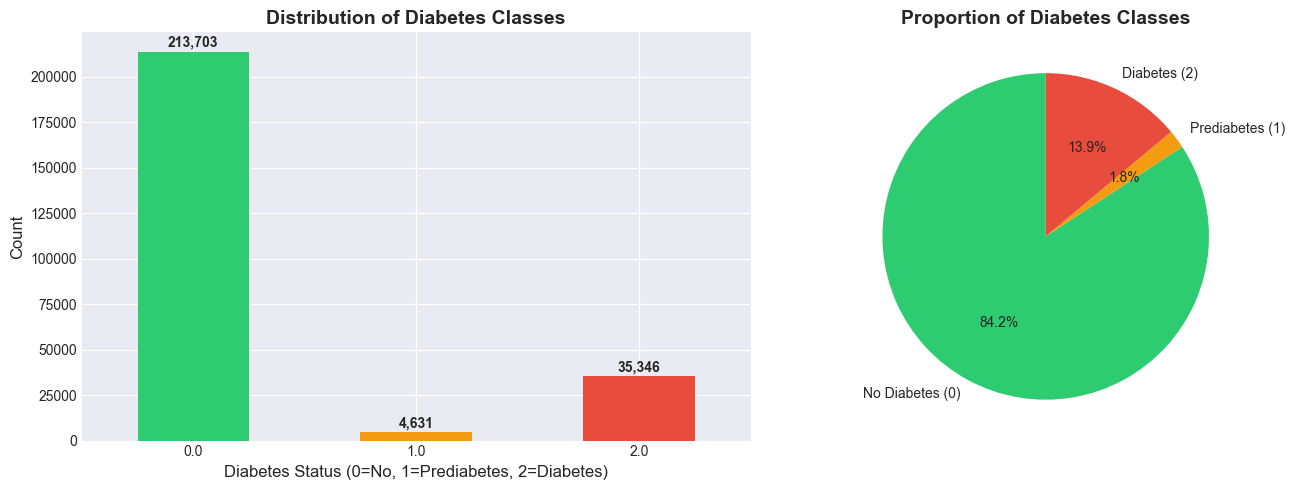

In [11]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Distribution of Diabetes Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diabetes Status (0=No, 1=Prediabetes, 2=Diabetes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels = ['No Diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)']
axes[1].pie(target_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Proportion of Diabetes Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Numerical Features Analysis

Key numerical features:
- **BMI**: Body Mass Index (key risk factor)
- **Age**: Age category (1-13)
- **MentHlth**: Days of poor mental health in past 30 days
- **PhysHlth**: Days of poor physical health in past 30 days

In [56]:
# Identify numerical features
numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age']

print("Statistical summary of key numerical features:")
df[numerical_features].describe()

Statistical summary of key numerical features:


,BMI,MentHlth,PhysHlth,Age
count,253680.000000,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081,8.032119
std,6.608694,7.412847,8.717951,3.054220
min,12.000000,0.000000,0.000000,1.000000
25%,24.000000,0.000000,0.000000,6.000000
50%,27.000000,0.000000,0.000000,8.000000
75%,31.000000,2.000000,3.000000,10.000000
max,98.000000,30.000000,30.000000,13.000000


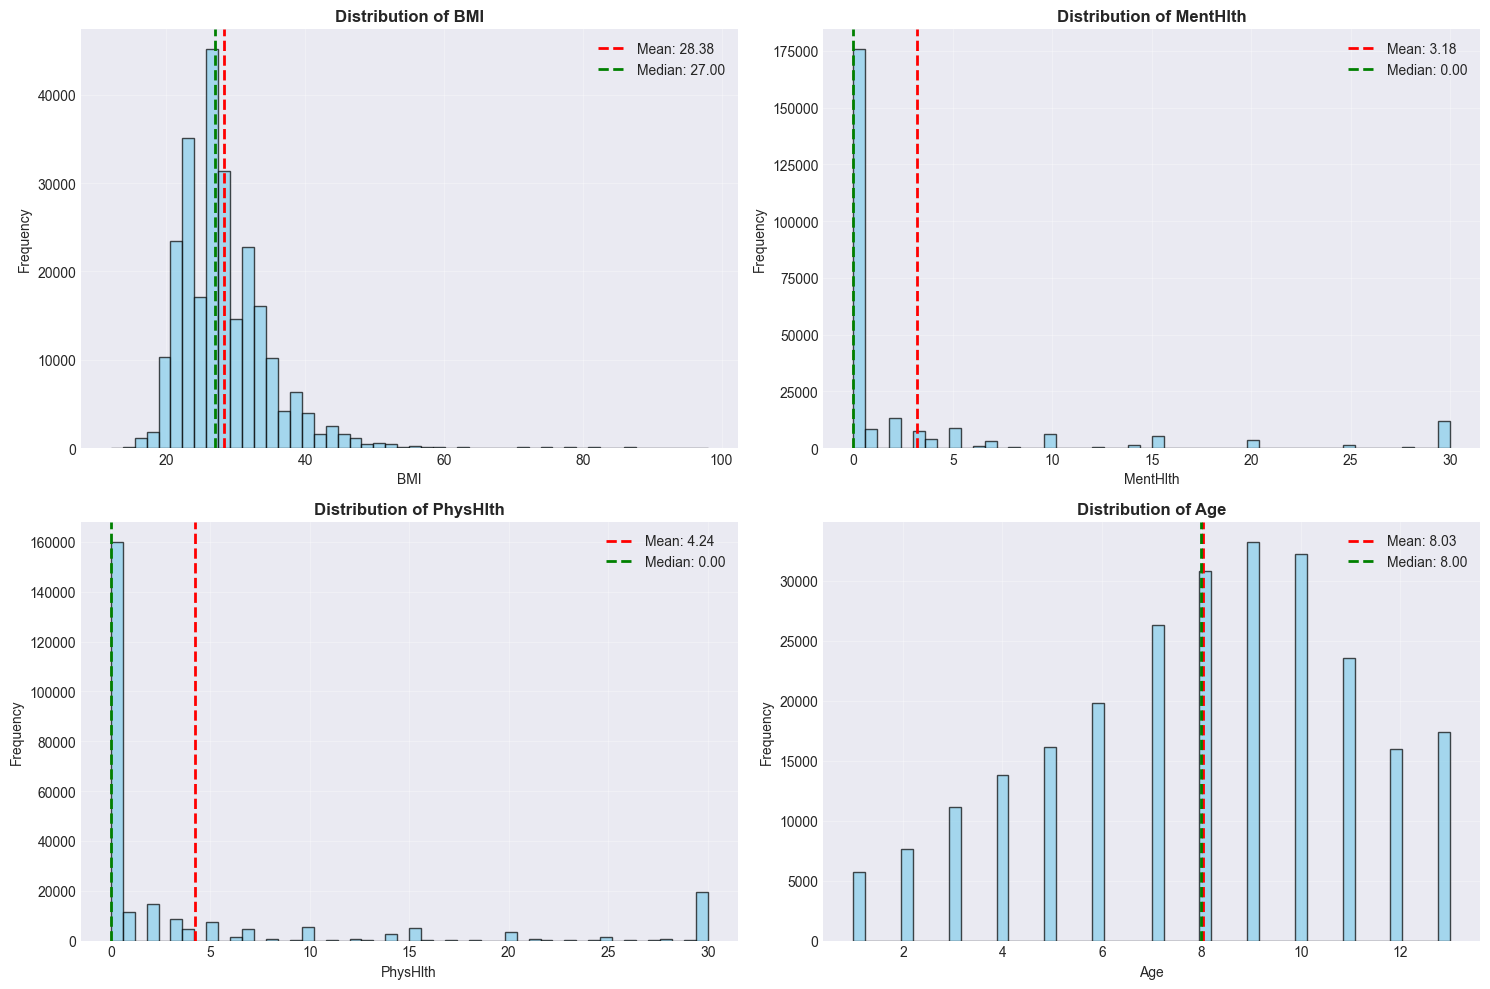

In [57]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {df[feature].mean():.2f}')
    axes[idx].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, 
                      label=f'Median: {df[feature].median():.2f}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

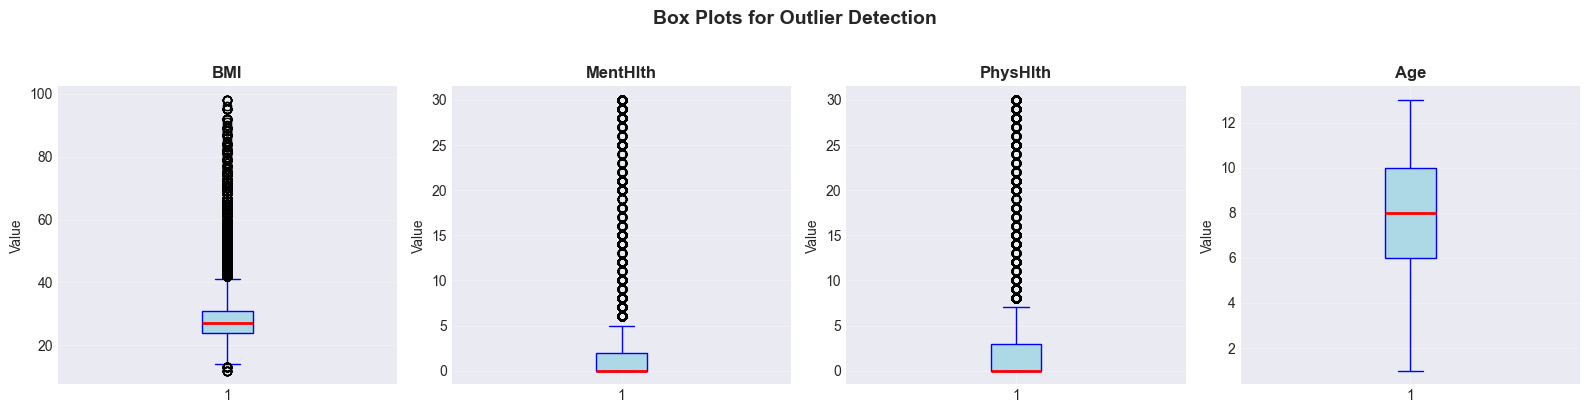

In [14]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, feature in enumerate(numerical_features):
    axes[idx].boxplot(df[feature], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='blue'),
                      whiskerprops=dict(color='blue'),
                      capprops=dict(color='blue'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Outlier detection using IQR method
print("Outlier Analysis (using IQR method):")
print("="*60)
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"{feature:15} : {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)")

Outlier Analysis (using IQR method):
BMI             : 9,847 outliers (3.88%)
MentHlth        : 36,208 outliers (14.27%)
PhysHlth        : 40,949 outliers (16.14%)
Age             : 0 outliers (0.00%)


## 5. Categorical Features Analysis

The dataset contains:
- **14 Binary Features**: Health conditions, lifestyle factors, demographics
- **3 Ordinal Features**: General Health, Education, Income

In [58]:
# Binary features
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                   'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                   'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

print("Binary Features Distribution:")
print("="*70)
for feature in binary_features:
    counts = df[feature].value_counts()
    print(f"\n{feature}:")
    print(f"  0 (No):  {counts.get(0.0, 0):,} ({counts.get(0.0, 0)/len(df)*100:.2f}%)")
    print(f"  1 (Yes): {counts.get(1.0, 0):,} ({counts.get(1.0, 0)/len(df)*100:.2f}%)")

Binary Features Distribution:

HighBP:
  0 (No):  144,851 (57.10%)
  1 (Yes): 108,829 (42.90%)

HighChol:
  0 (No):  146,089 (57.59%)
  1 (Yes): 107,591 (42.41%)

CholCheck:
  0 (No):  9,470 (3.73%)
  1 (Yes): 244,210 (96.27%)

Smoker:
  0 (No):  141,257 (55.68%)
  1 (Yes): 112,423 (44.32%)

Stroke:
  0 (No):  243,388 (95.94%)
  1 (Yes): 10,292 (4.06%)

HeartDiseaseorAttack:
  0 (No):  229,787 (90.58%)
  1 (Yes): 23,893 (9.42%)

PhysActivity:
  0 (No):  61,760 (24.35%)
  1 (Yes): 191,920 (75.65%)

Fruits:
  0 (No):  92,782 (36.57%)
  1 (Yes): 160,898 (63.43%)

Veggies:
  0 (No):  47,839 (18.86%)
  1 (Yes): 205,841 (81.14%)

HvyAlcoholConsump:
  0 (No):  239,424 (94.38%)
  1 (Yes): 14,256 (5.62%)

AnyHealthcare:
  0 (No):  12,417 (4.89%)
  1 (Yes): 241,263 (95.11%)

NoDocbcCost:
  0 (No):  232,326 (91.58%)
  1 (Yes): 21,354 (8.42%)

DiffWalk:
  0 (No):  211,005 (83.18%)
  1 (Yes): 42,675 (16.82%)

Sex:
  0 (No):  141,974 (55.97%)
  1 (Yes): 111,706 (44.03%)


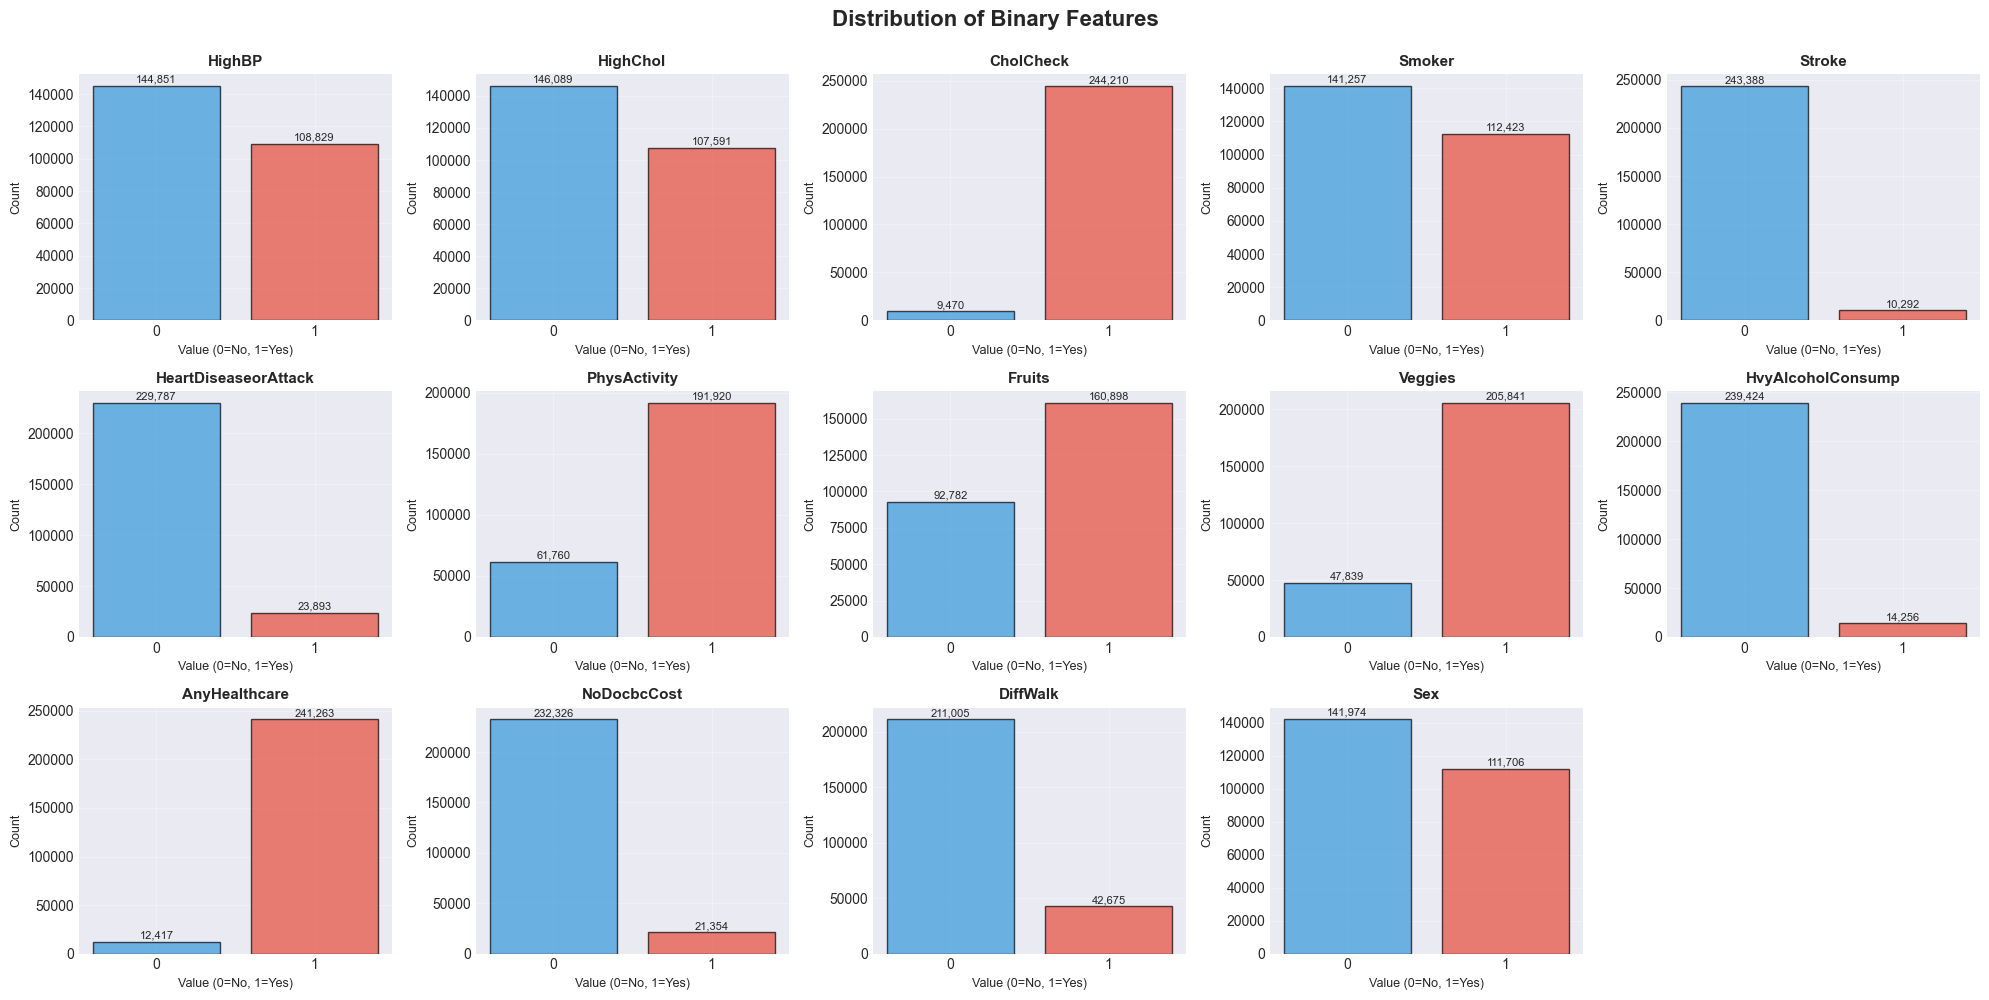

In [82]:
# Visualize binary features
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(binary_features):
    counts = df[feature].value_counts().sort_index()
    axes[idx].bar([0, 1], counts.values, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value (0=No, 1=Yes)', fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].set_xticks([0, 1])
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=8)
    axes[idx].grid(alpha=0.3)

# Hide the last empty subplot
axes[-1].axis('off')

plt.suptitle('Distribution of Binary Features', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [59]:
# Ordinal features
ordinal_features = ['GenHlth', 'Education', 'Income']

print("Ordinal Features Distribution:")
for feature in ordinal_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts().sort_index())

Ordinal Features Distribution:

GenHlth:
GenHlth
1.0    45299
2.0    89084
3.0    75646
4.0    31570
5.0    12081
Name: count, dtype: int64

Education:
Education
1.0       174
2.0      4043
3.0      9478
4.0     62750
5.0     69910
6.0    107325
Name: count, dtype: int64

Income:
Income
1.0     9811
2.0    11783
3.0    15994
4.0    20135
5.0    25883
6.0    36470
7.0    43219
8.0    90385
Name: count, dtype: int64


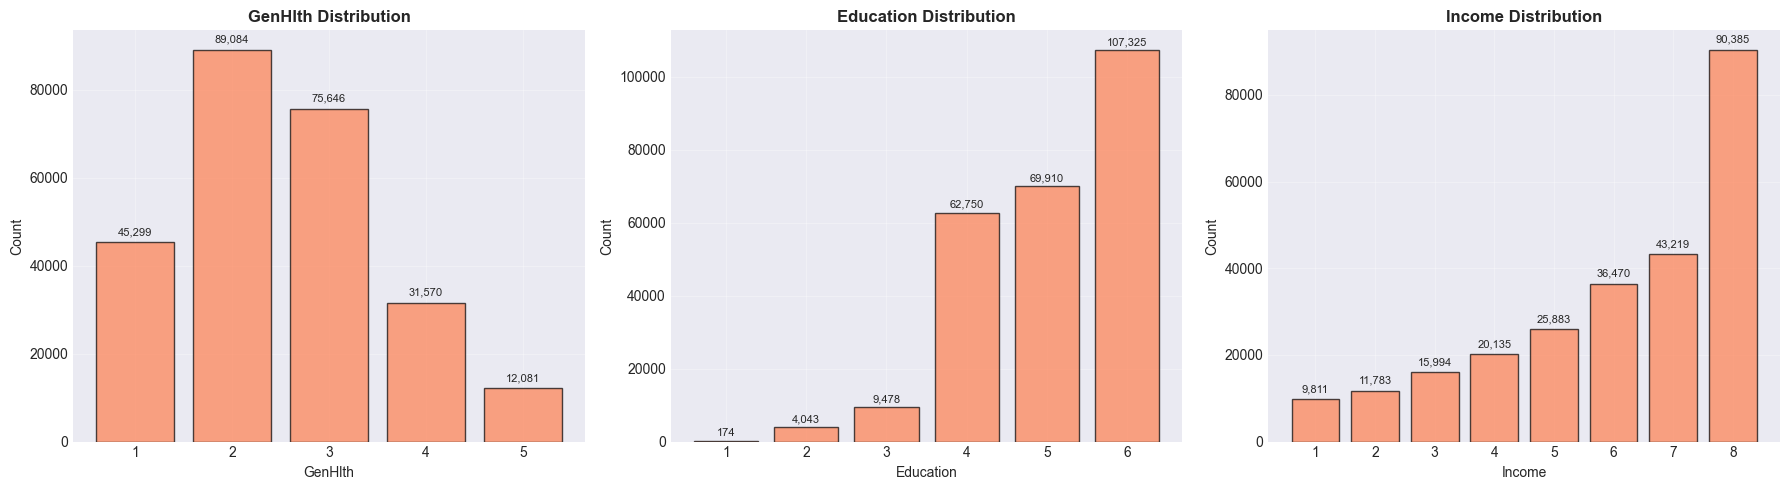

In [78]:
# Visualize ordinal features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(ordinal_features):
    counts = df[feature].value_counts().sort_index()
    axes[idx].bar(counts.index, counts.values, color='coral', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    for i, v in enumerate(counts.values):
        axes[idx].text(i+1, v+3500, f'{v:,}', ha='center', va='top', fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Bivariate Analysis - Numerical Features vs Target

Examining how numerical features differ across diabetes classes

In [20]:
# Group statistics by diabetes status
print("Mean values of numerical features by Diabetes status:")
grouped_means = df.groupby('Diabetes_012')[numerical_features].mean()
print(grouped_means)

print("\nMedian values of numerical features by Diabetes status:")
grouped_medians = df.groupby('Diabetes_012')[numerical_features].median()
print(grouped_medians)

Mean values of numerical features by Diabetes status:
                    BMI  MentHlth  PhysHlth       Age
Diabetes_012                                         
0.0           27.742521  2.944404  3.582416  7.786559
1.0           30.724466  4.529907  6.348305  9.083351
2.0           31.944011  4.461806  7.954479  9.379053

Median values of numerical features by Diabetes status:
               BMI  MentHlth  PhysHlth   Age
Diabetes_012                                
0.0           27.0       0.0       0.0   8.0
1.0           30.0       0.0       0.0   9.0
2.0           31.0       0.0       1.0  10.0


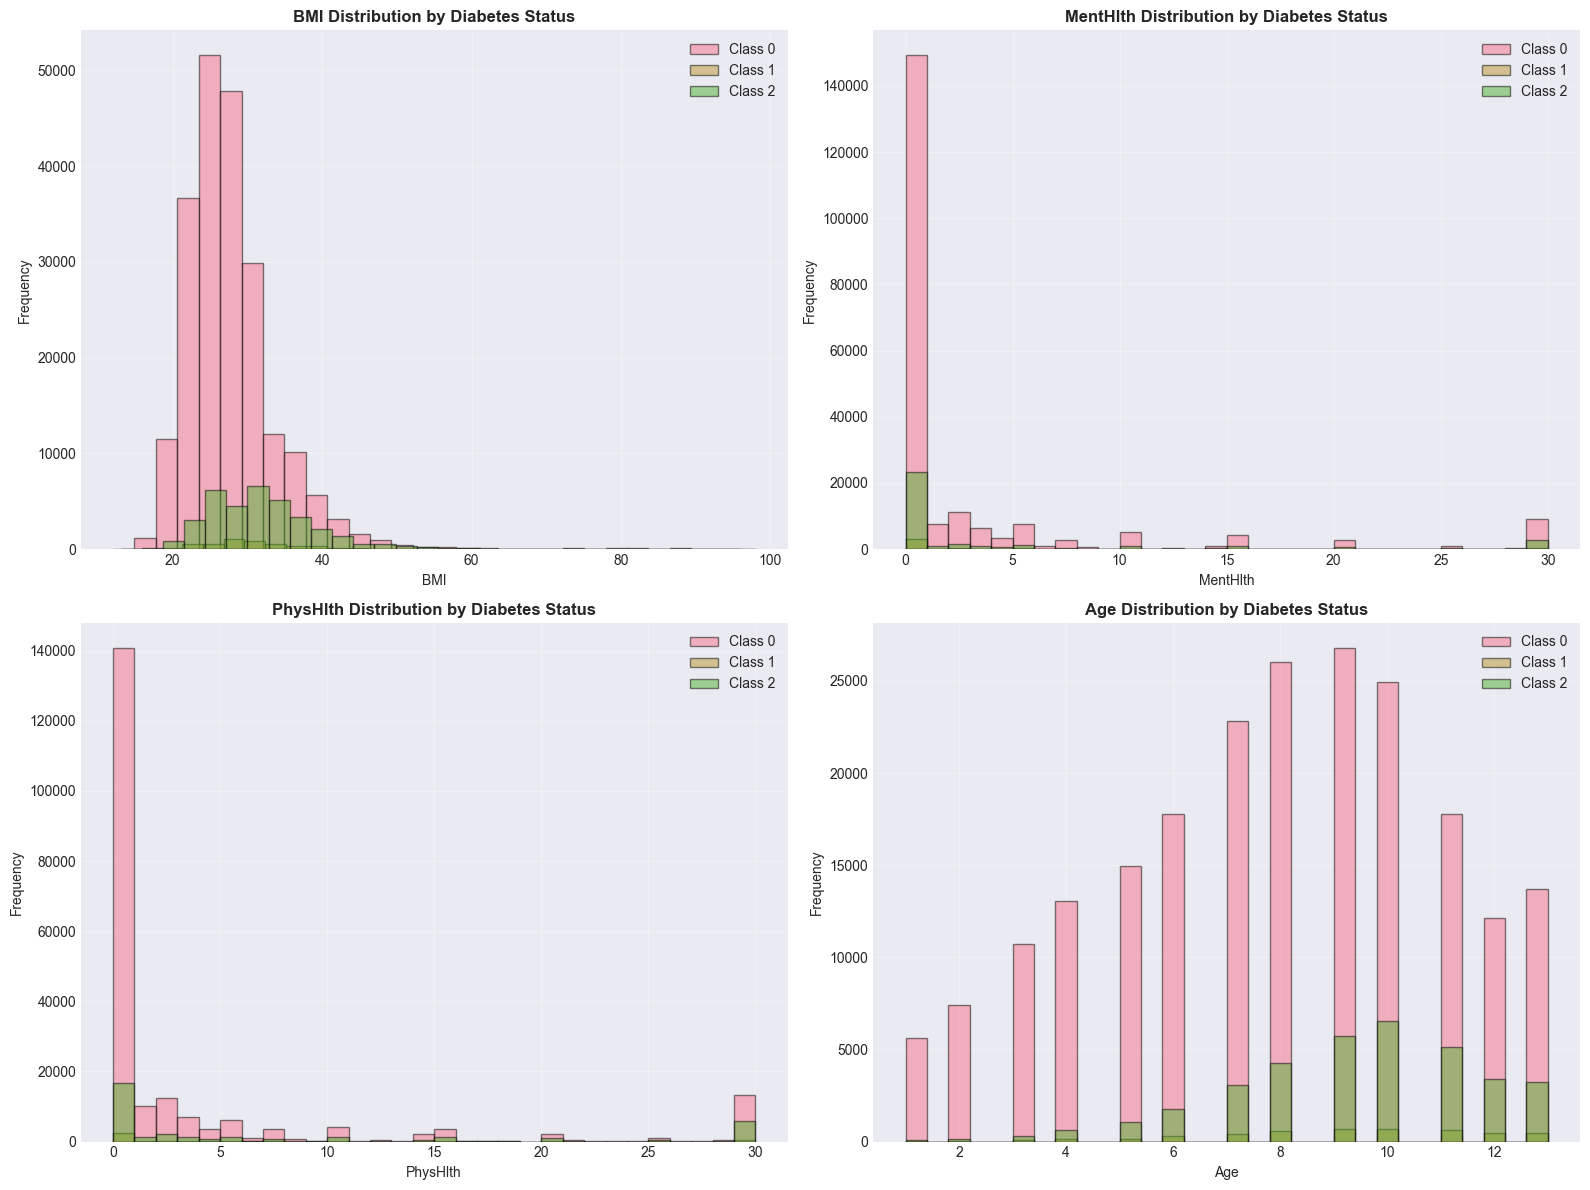

In [21]:
# Visualize numerical features by diabetes status - Histograms
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    for diabetes_class in sorted(df['Diabetes_012'].unique()):
        data = df[df['Diabetes_012'] == diabetes_class][feature]
        axes[idx].hist(data, bins=30, alpha=0.5,
                      label=f'Class {int(diabetes_class)}',
                      edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution by Diabetes Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

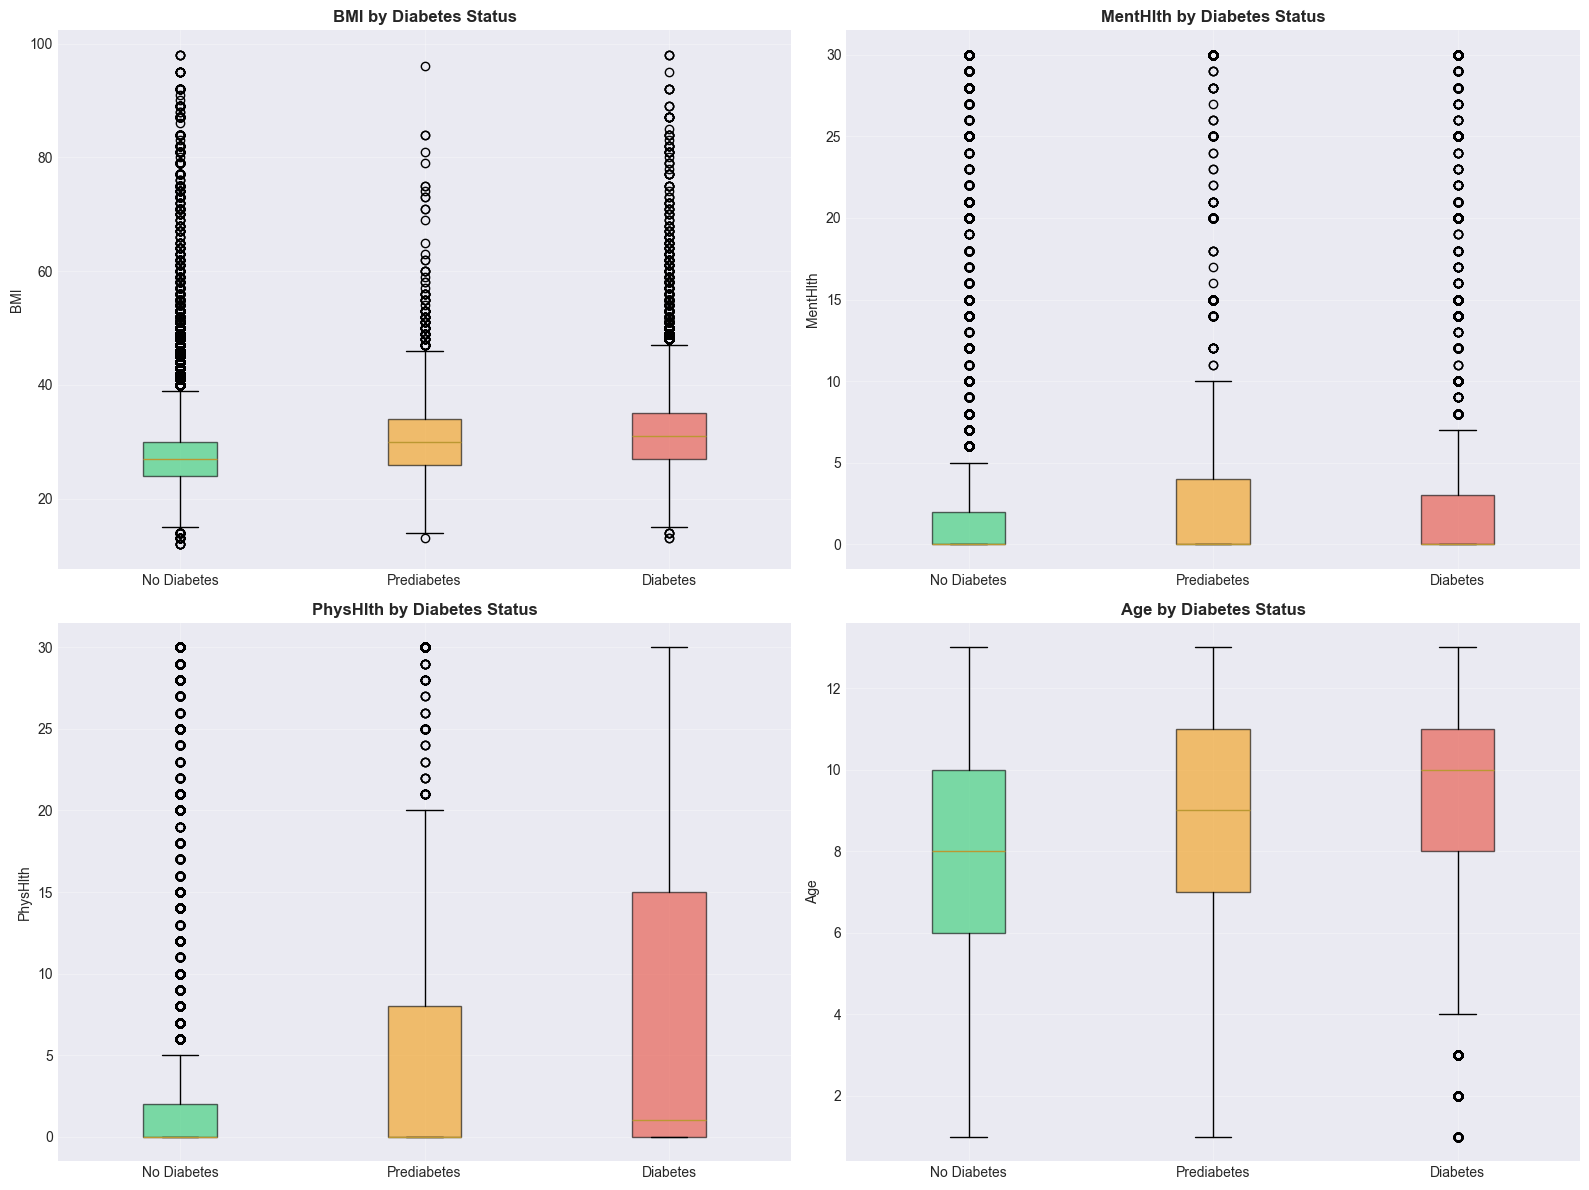

In [22]:
# Box plots by diabetes status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    data_to_plot = [df[df['Diabetes_012'] == cls][feature] for cls in sorted(df['Diabetes_012'].unique())]
    bp = axes[idx].boxplot(data_to_plot, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
                           patch_artist=True)

    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[idx].set_title(f'{feature} by Diabetes Status', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ANOVA test for numerical features
print("ANOVA Test Results (Numerical Features vs Diabetes Status):")
print("="*70)
print(f"{'Feature':<15} | {'F-statistic':<15} | {'p-value':<15} | {'Significance'}")
print("="*70)
for feature in numerical_features:
    groups = [df[df['Diabetes_012'] == cls][feature] for cls in sorted(df['Diabetes_012'].unique())]
    f_stat, p_value = f_oneway(*groups)
    sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns"))
    print(f"{feature:<15} | {f_stat:<15.2f} | {p_value:<15.4e} | {sig}")
print("="*70)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

ANOVA Test Results (Numerical Features vs Diabetes Status):
Feature         | F-statistic     | p-value         | Significance
BMI             | 6768.36         | 0.0000e+00      | ***
MentHlth        | 717.12          | 2.7352e-311     | ***
PhysHlth        | 4078.70         | 0.0000e+00      | ***
Age             | 4560.44         | 0.0000e+00      | ***
Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


## 7. Bivariate Analysis - Categorical Features vs Target

Examining the relationship between categorical features and diabetes status

In [24]:
# Analyze binary features by diabetes status
print("Percentage of positive cases (=1) for binary features by Diabetes status:")
binary_by_diabetes = pd.DataFrame()
for feature in binary_features:
    percentages = df.groupby('Diabetes_012')[feature].mean() * 100
    binary_by_diabetes[feature] = percentages
binary_by_diabetes.T

Percentage of positive cases (=1) for binary features by Diabetes status:


Diabetes_012,0.0,1.0,2.0
HighBP,37.113190,62.902181,75.267357
HighChol,37.917109,62.081624,67.011826
CholCheck,95.710402,98.661196,99.318169
Smoker,42.968044,49.276614,51.821988
Stroke,3.162801,5.722306,9.245742
HeartDiseaseorAttack,7.183334,14.338156,22.288236
PhysActivity,77.907657,67.847117,63.053811
Fruits,64.302326,60.224574,58.544107
Veggies,82.143910,76.894839,75.640808
HvyAlcoholConsump,6.184284,4.491471,2.353873


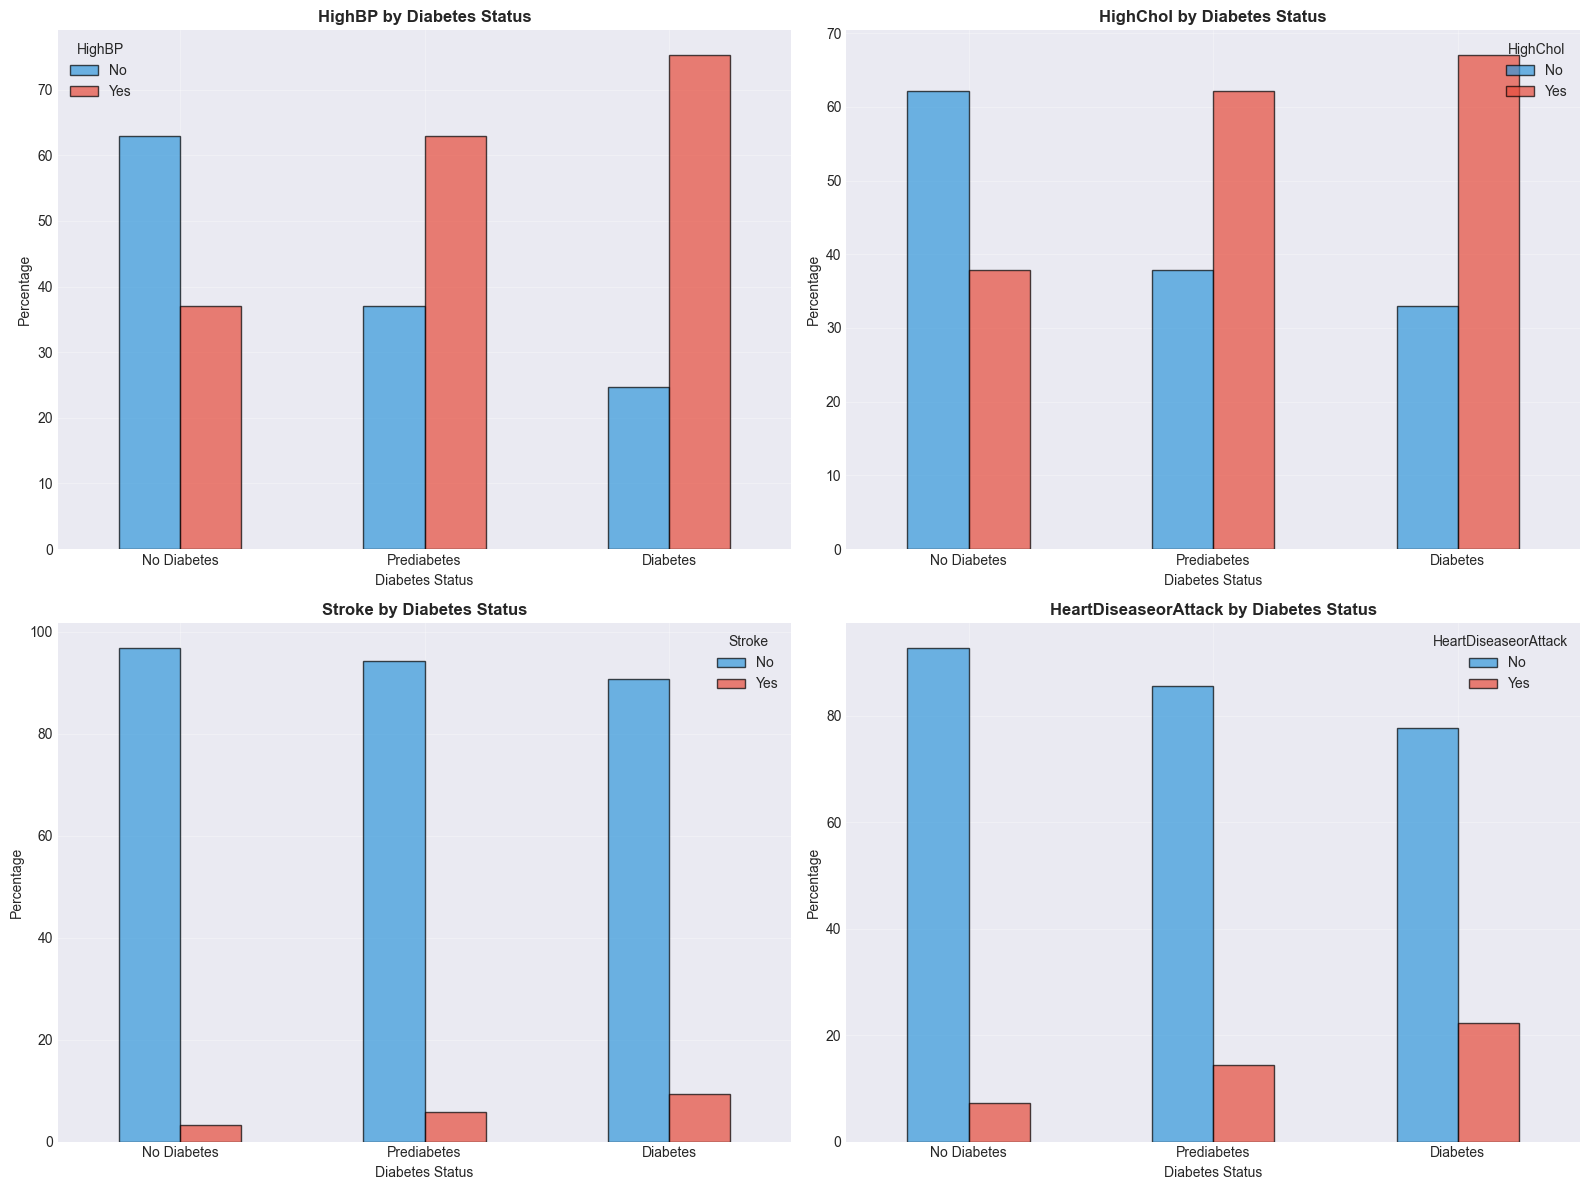

In [25]:
# Visualize health conditions by diabetes status
health_conditions = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(health_conditions):
    crosstab = pd.crosstab(df['Diabetes_012'], df[feature], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c'],
                  alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature} by Diabetes Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Diabetes Status', fontsize=10)
    axes[idx].set_ylabel('Percentage', fontsize=10)
    axes[idx].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'], rotation=0)
    axes[idx].legend(['No', 'Yes'], title=feature)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

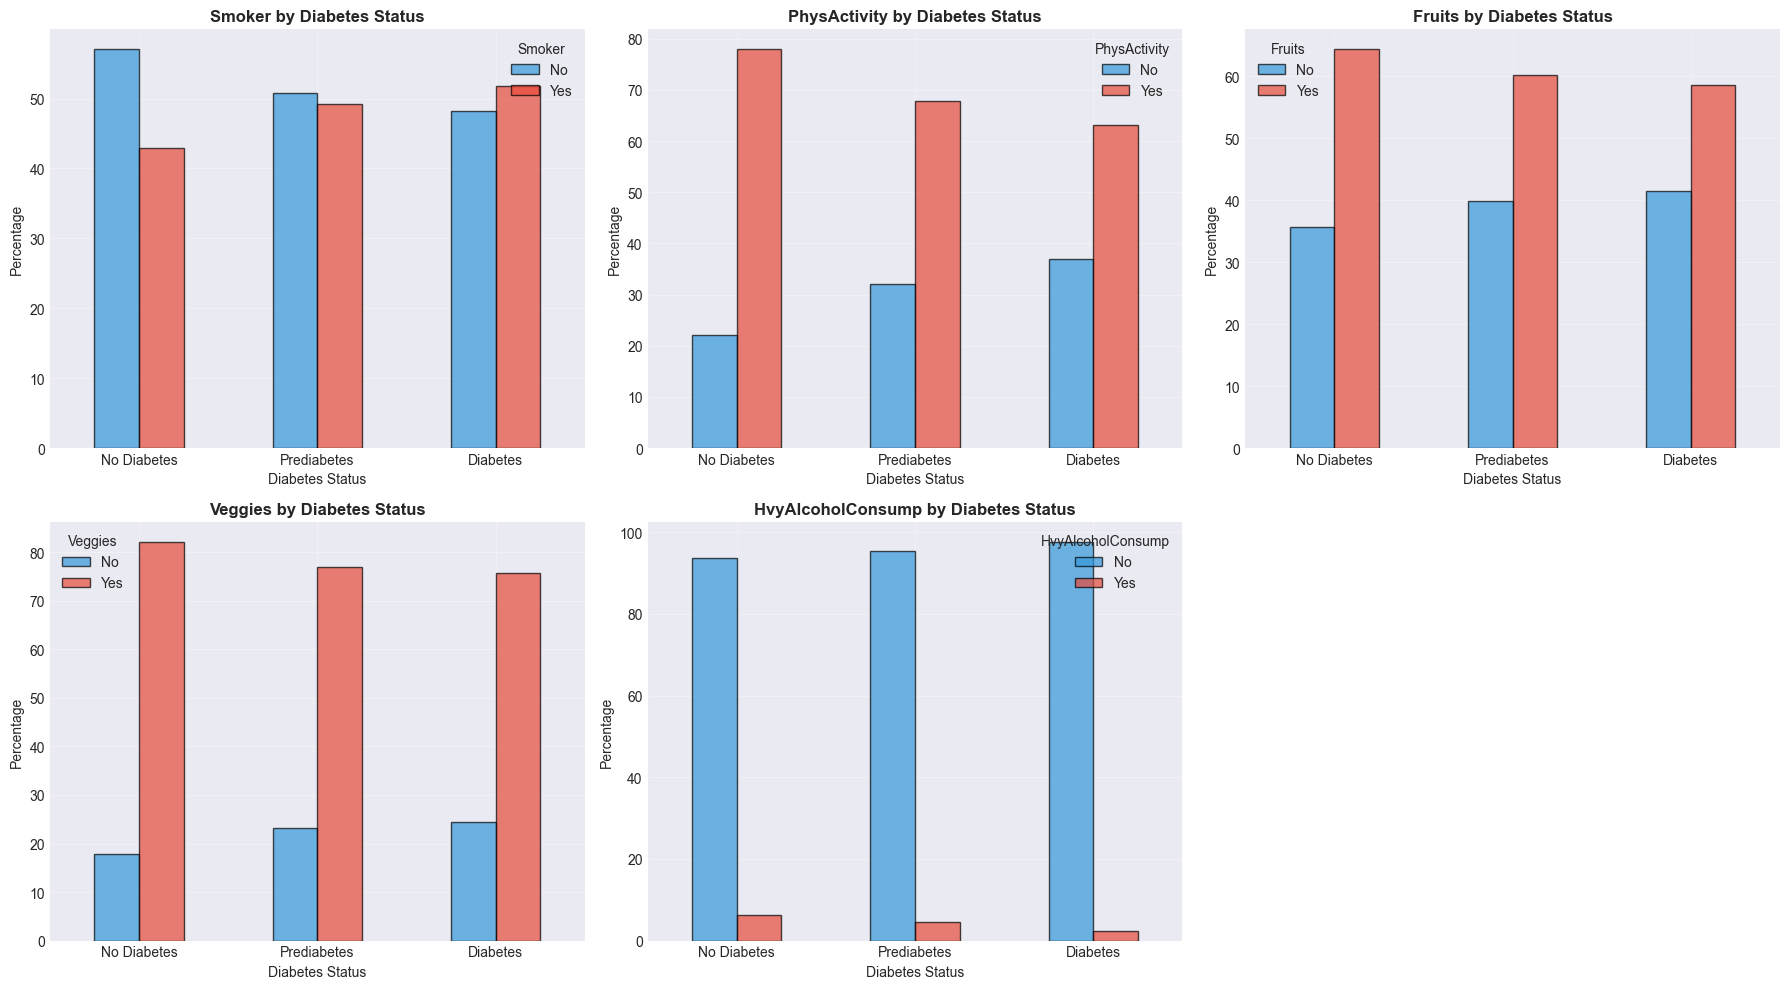

In [26]:
# Visualize lifestyle features by diabetes status
lifestyle_features = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(lifestyle_features):
    crosstab = pd.crosstab(df['Diabetes_012'], df[feature], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c'],
                  alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature} by Diabetes Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Diabetes Status', fontsize=10)
    axes[idx].set_ylabel('Percentage', fontsize=10)
    axes[idx].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'], rotation=0)
    axes[idx].legend(['No', 'Yes'], title=feature)
    axes[idx].grid(alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
# Chi-square test for categorical features
print("Chi-Square Test Results (Categorical Features vs Diabetes Status):")
print("="*80)
print(f"{'Feature':<25} | {'Chi2':<12} | {'p-value':<15} | {'Significance'}")
print("="*80)
for feature in binary_features:
    contingency_table = pd.crosstab(df['Diabetes_012'], df[feature])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns"))
    print(f"{feature:<25} | {chi2:<12.2f} | {p_value:<15.4e} | {sig}")
print("="*80)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

Chi-Square Test Results (Categorical Features vs Diabetes Status):
Feature                   | Chi2         | p-value         | Significance
HighBP                    | 18794.64     | 0.0000e+00      | ***
HighChol                  | 11258.92     | 0.0000e+00      | ***
CholCheck                 | 1173.75      | 1.3291e-255     | ***
Smoker                    | 1010.51      | 3.7167e-220     | ***
Stroke                    | 2916.75      | 0.0000e+00      | ***
HeartDiseaseorAttack      | 8244.89      | 0.0000e+00      | ***
PhysActivity              | 3789.30      | 0.0000e+00      | ***
Fruits                    | 454.35       | 2.1867e-99      | ***
Veggies                   | 893.84       | 8.0296e-195     | ***
HvyAlcoholConsump         | 850.32       | 2.2619e-185     | ***
AnyHealthcare             | 69.08        | 9.9979e-16      | ***
NoDocbcCost               | 396.08       | 9.8158e-87      | ***
DiffWalk                  | 12776.94     | 0.0000e+00      | ***
Sex           

## 8. Correlation Analysis

Understanding relationships between all features

In [28]:
# Calculate correlation matrix
correlation_matrix = df.corr()

print("Top 15 Correlations with Diabetes_012:")
diabetes_corr = correlation_matrix['Diabetes_012'].sort_values(ascending=False)
print(diabetes_corr.head(15))

Top 15 Correlations with Diabetes_012:
Diabetes_012            1.000000
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
Name: Diabetes_012, dtype: float64


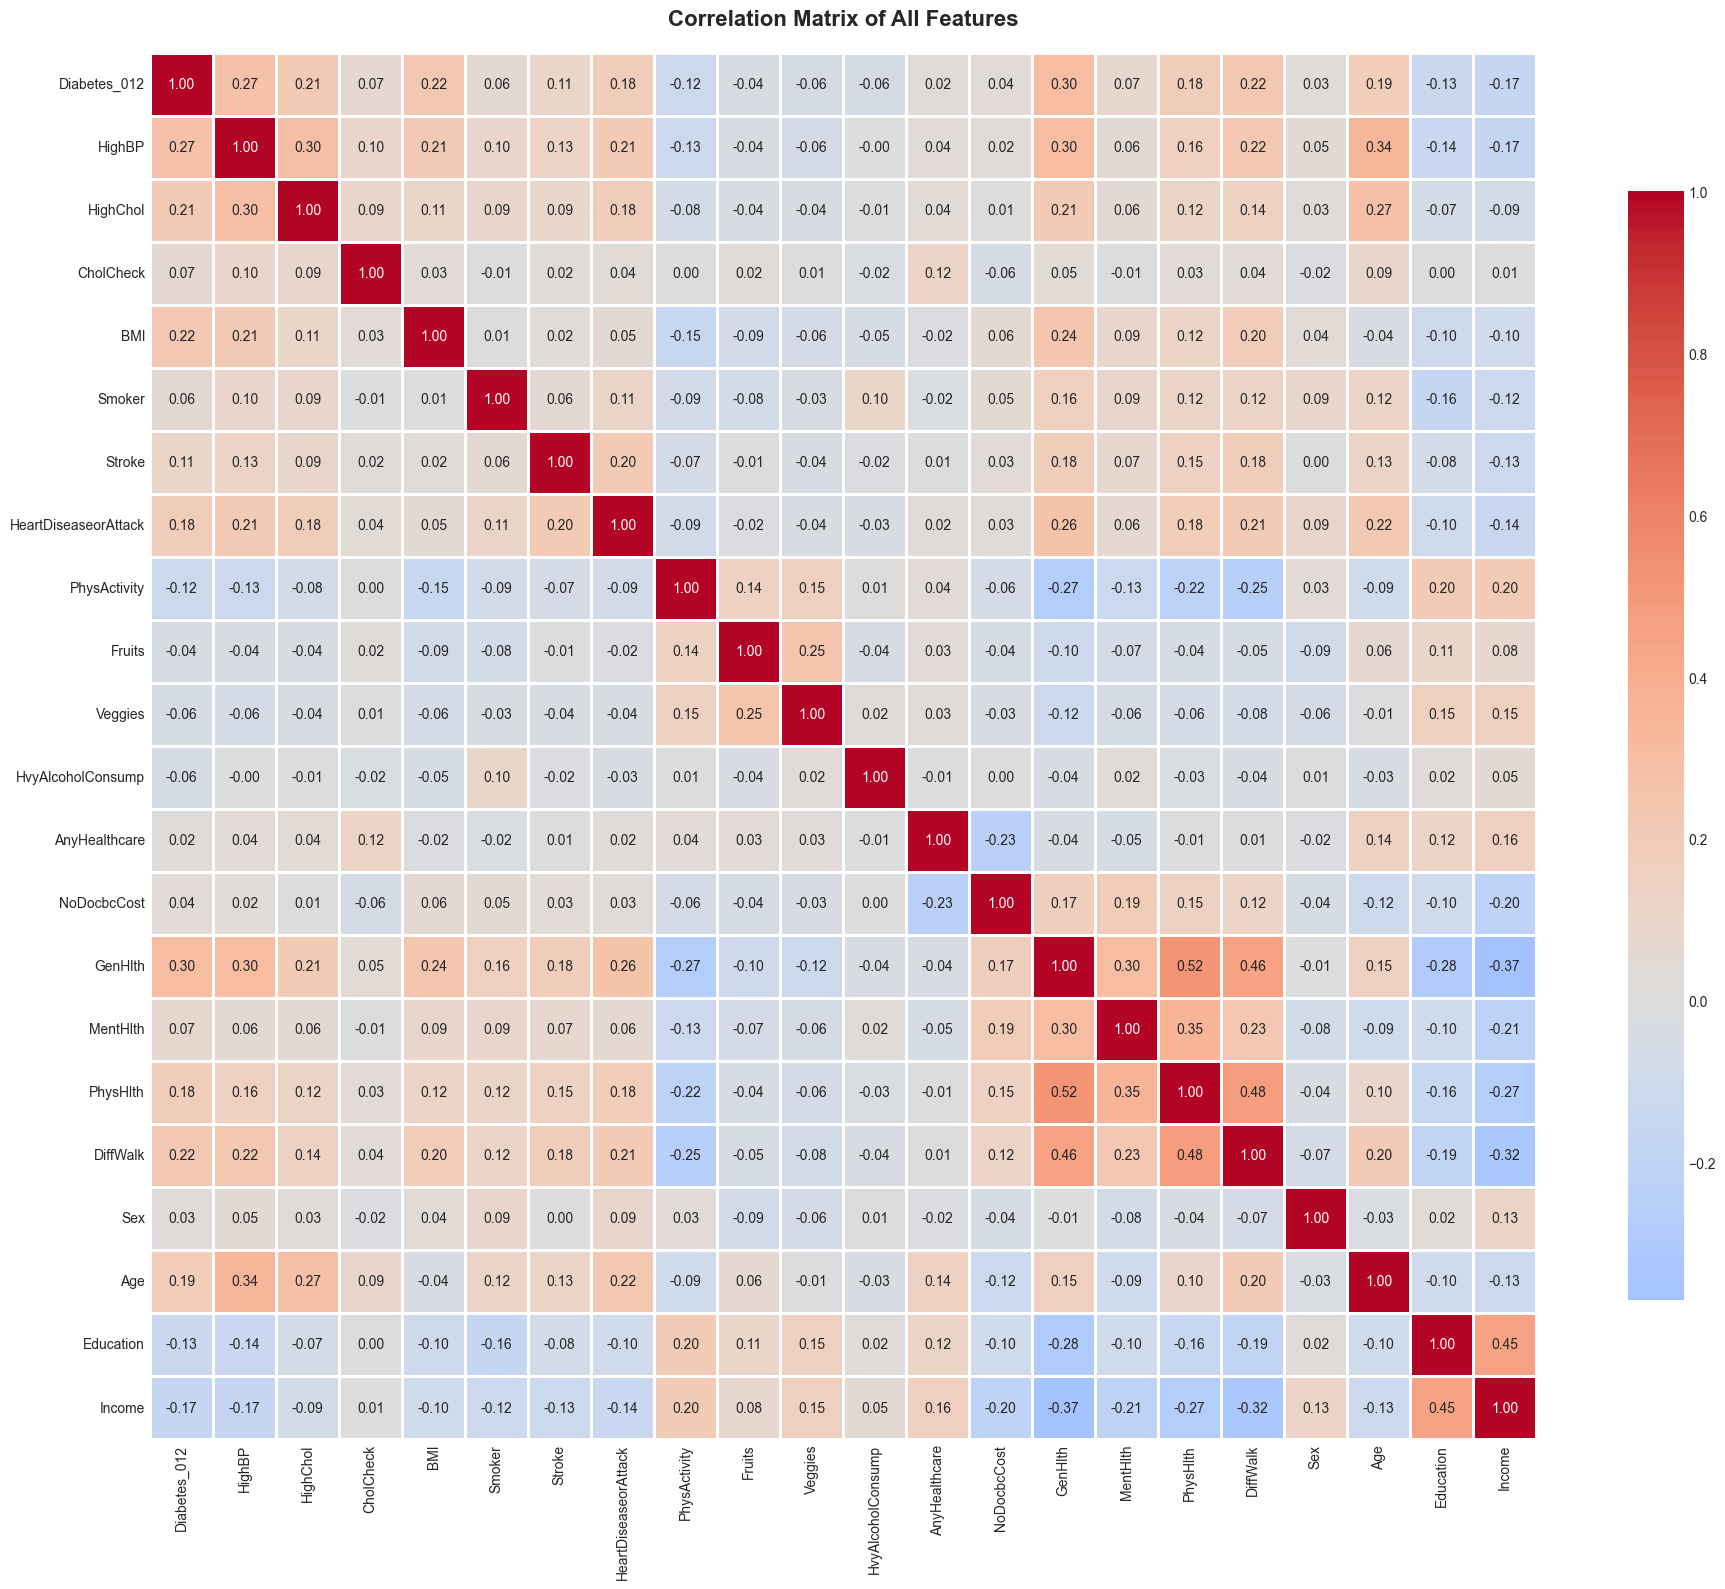

In [29]:
# Visualize correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

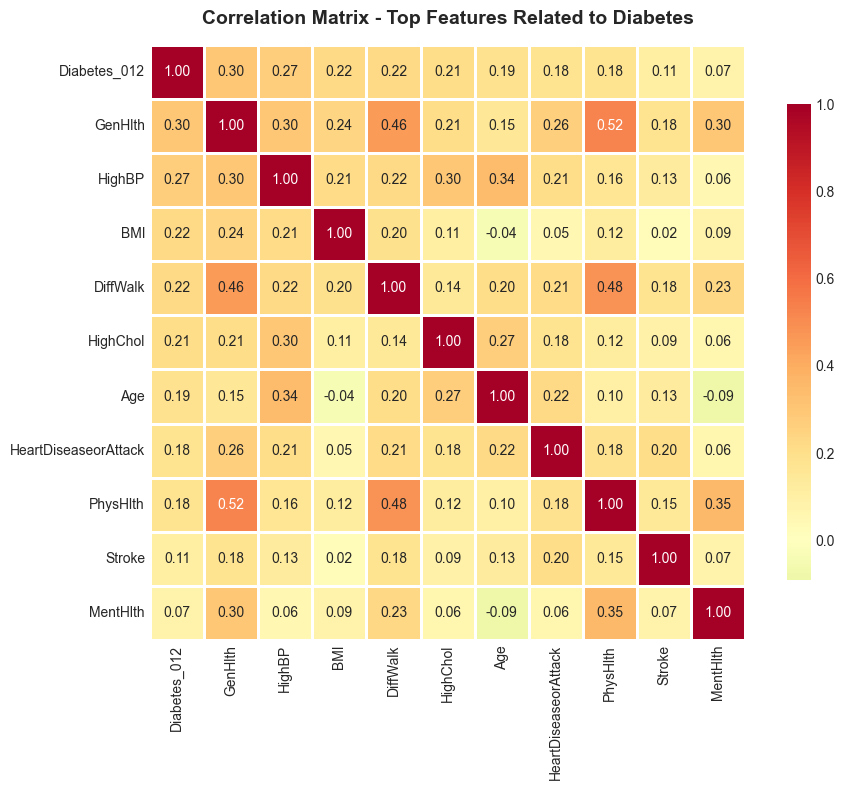

In [30]:
# Focus on features highly correlated with diabetes
plt.figure(figsize=(10, 8))
top_features = diabetes_corr.head(11).index.tolist()  # Top 10 + target itself
top_corr_matrix = df[top_features].corr()
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features Related to Diabetes', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 9. Multivariate Analysis

Exploring relationships between multiple features simultaneously

Generating pairplot for numerical features (using 5000 random samples)...


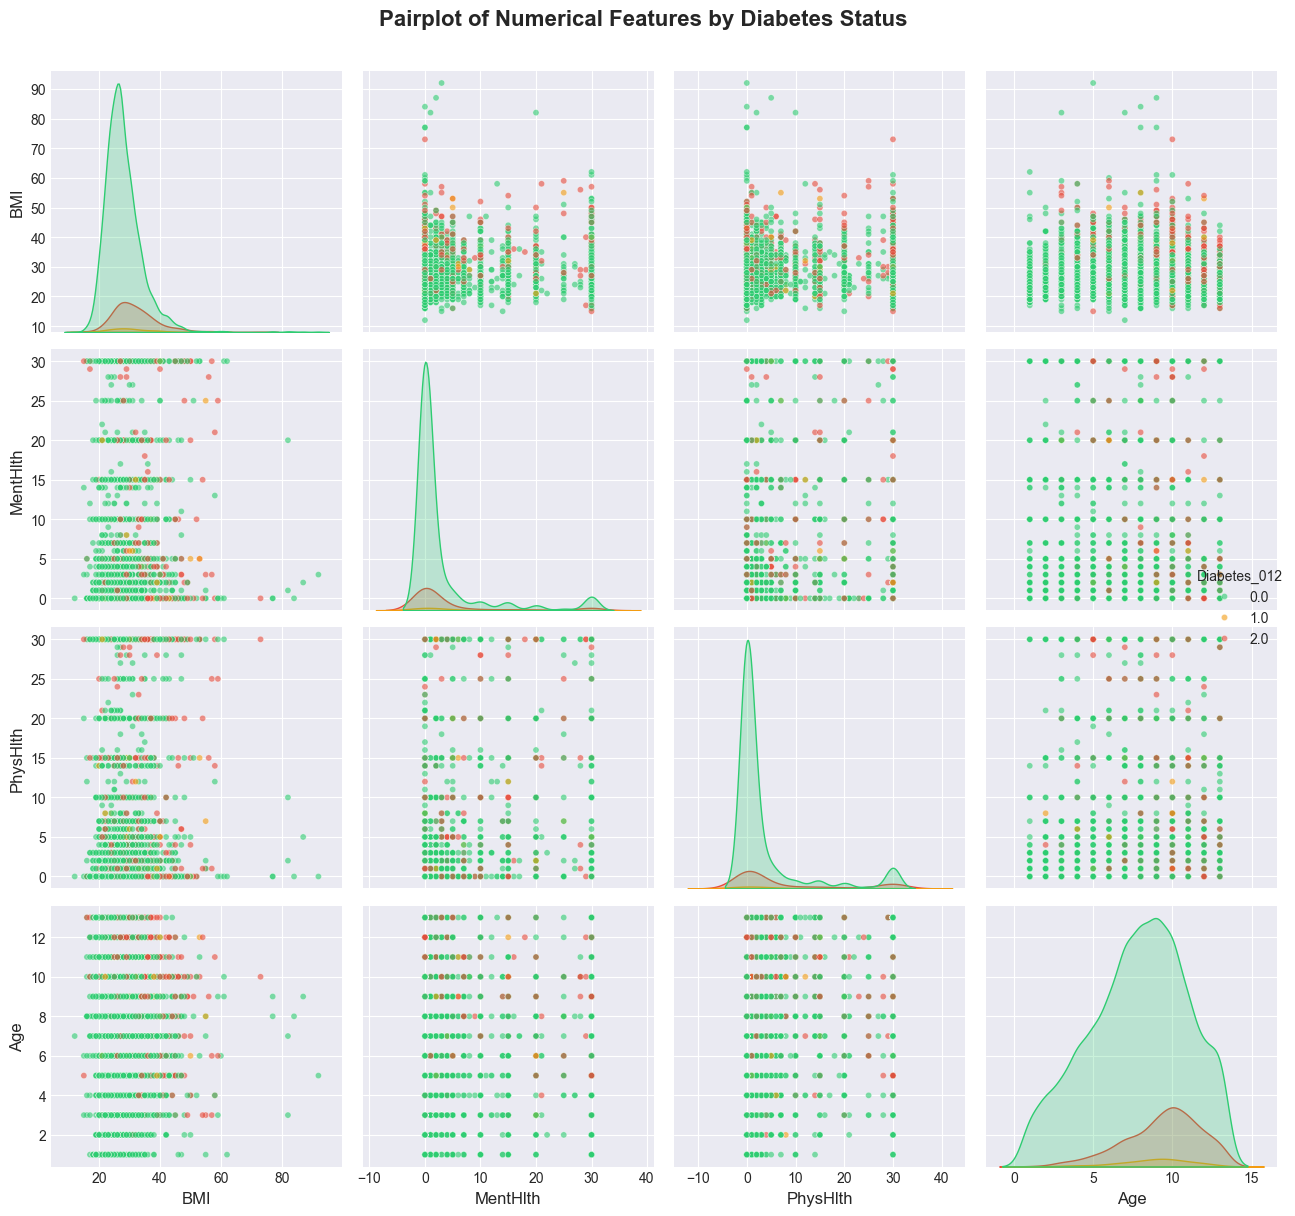

Pairplot generated successfully!


In [31]:
# Pairplot for numerical features (using a sample for efficiency)
print("Generating pairplot for numerical features (using 5000 random samples)...")
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
pairplot_features = numerical_features + ['Diabetes_012']

pairplot_fig = sns.pairplot(sample_df[pairplot_features],
                            hue='Diabetes_012',
                            palette={0.0: '#2ecc71', 1.0: '#f39c12', 2.0: '#e74c3c'},
                            diag_kind='kde',
                            plot_kws={'alpha': 0.6, 's': 20},
                            height=3)
pairplot_fig.figure.suptitle('Pairplot of Numerical Features by Diabetes Status',
                             y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("Pairplot generated successfully!")

## 10. Health Conditions Co-occurrence Analysis

Understanding how health conditions appear together

In [32]:
# Create health risk score
df['HealthRiskScore'] = (df['HighBP'] + df['HighChol'] + df['Stroke'] +
                          df['HeartDiseaseorAttack'] + df['DiffWalk'])

print("Health Risk Score Distribution:")
print(df['HealthRiskScore'].value_counts().sort_index())

print("\nMean Health Risk Score by Diabetes Status:")
print(df.groupby('Diabetes_012')['HealthRiskScore'].mean())

Health Risk Score Distribution:
HealthRiskScore
0.0    91062
1.0    75251
2.0    54723
3.0    23590
4.0     7457
5.0     1597
Name: count, dtype: int64

Mean Health Risk Score by Diabetes Status:
Diabetes_012
0.0    0.986046
1.0    1.727921
2.0    2.109348
Name: HealthRiskScore, dtype: float64


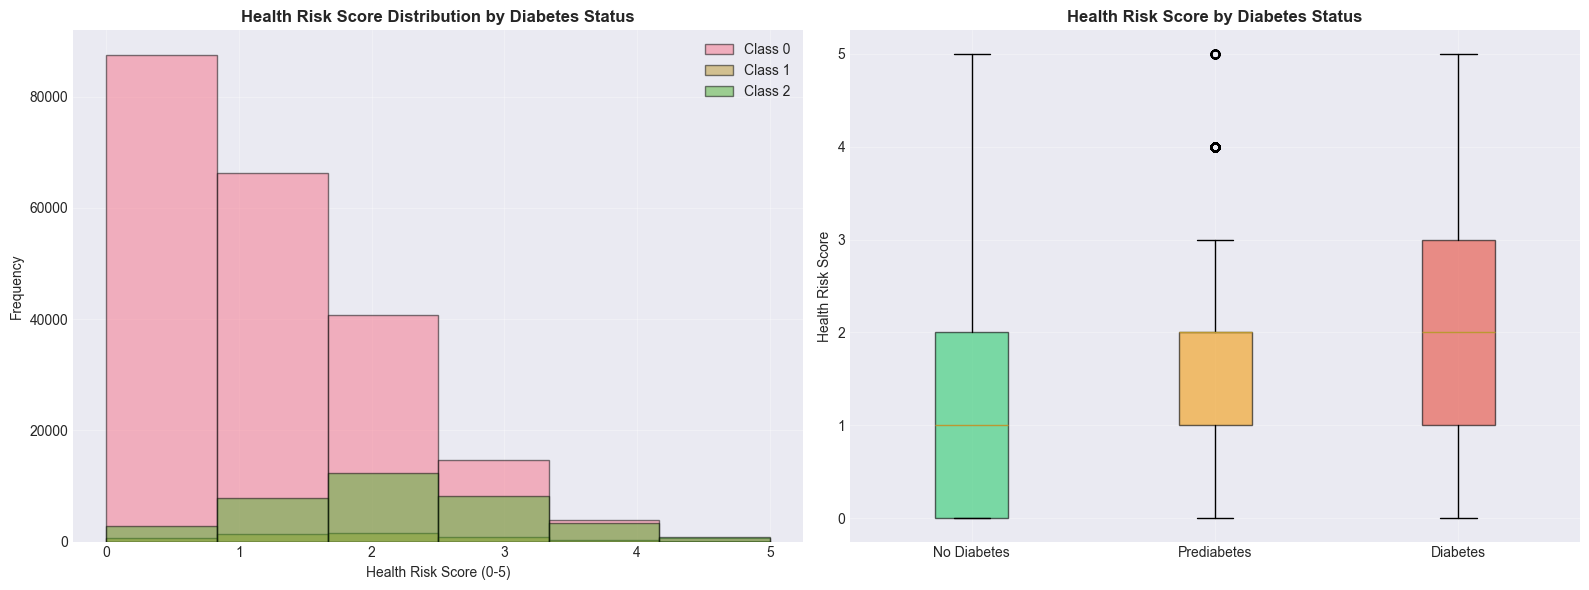

In [33]:
# Visualize health risk score by diabetes status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution
for diabetes_class in sorted(df['Diabetes_012'].unique()):
    data = df[df['Diabetes_012'] == diabetes_class]['HealthRiskScore']
    axes[0].hist(data, bins=6, alpha=0.5, label=f'Class {int(diabetes_class)}',
                edgecolor='black')
axes[0].set_title('Health Risk Score Distribution by Diabetes Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Health Risk Score (0-5)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [df[df['Diabetes_012'] == cls]['HealthRiskScore']
                for cls in sorted(df['Diabetes_012'].unique())]
bp = axes[1].boxplot(data_to_plot, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
                     patch_artist=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Health Risk Score by Diabetes Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Health Risk Score', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: Unknown format code 'd' for object of type 'float'

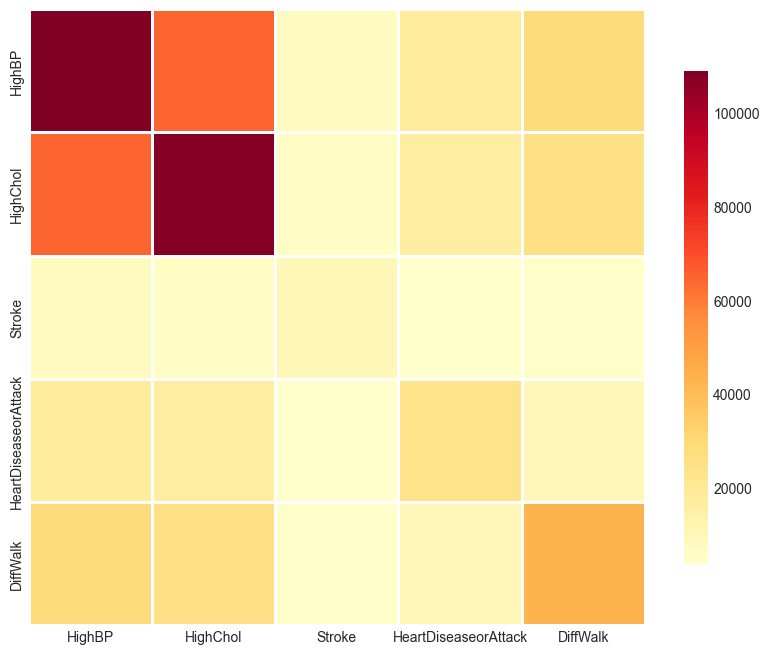

In [34]:
# Co-occurrence matrix of health conditions
health_cond = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'DiffWalk']
cooccurrence = df[health_cond].T.dot(df[health_cond])

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True,
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Co-occurrence Matrix of Health Conditions', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 11. Lifestyle Factors Analysis

Examining the impact of lifestyle choices on diabetes risk

In [35]:
# Create lifestyle score (higher is better)
df['LifestyleScore'] = df['PhysActivity'] + df['Fruits'] + df['Veggies'] - df['HvyAlcoholConsump']

print("Lifestyle Score Distribution:")
print(df['LifestyleScore'].value_counts().sort_index())

print("\nMean Lifestyle Score by Diabetes Status:")
print(df.groupby('Diabetes_012')['LifestyleScore'].mean())

Lifestyle Score Distribution:
LifestyleScore
-1.0       632
 0.0     13928
 1.0     43894
 2.0     84537
 3.0    110689
Name: count, dtype: int64

Mean Lifestyle Score by Diabetes Status:
Diabetes_012
0.0    2.181696
1.0    2.004751
2.0    1.948849
Name: LifestyleScore, dtype: float64


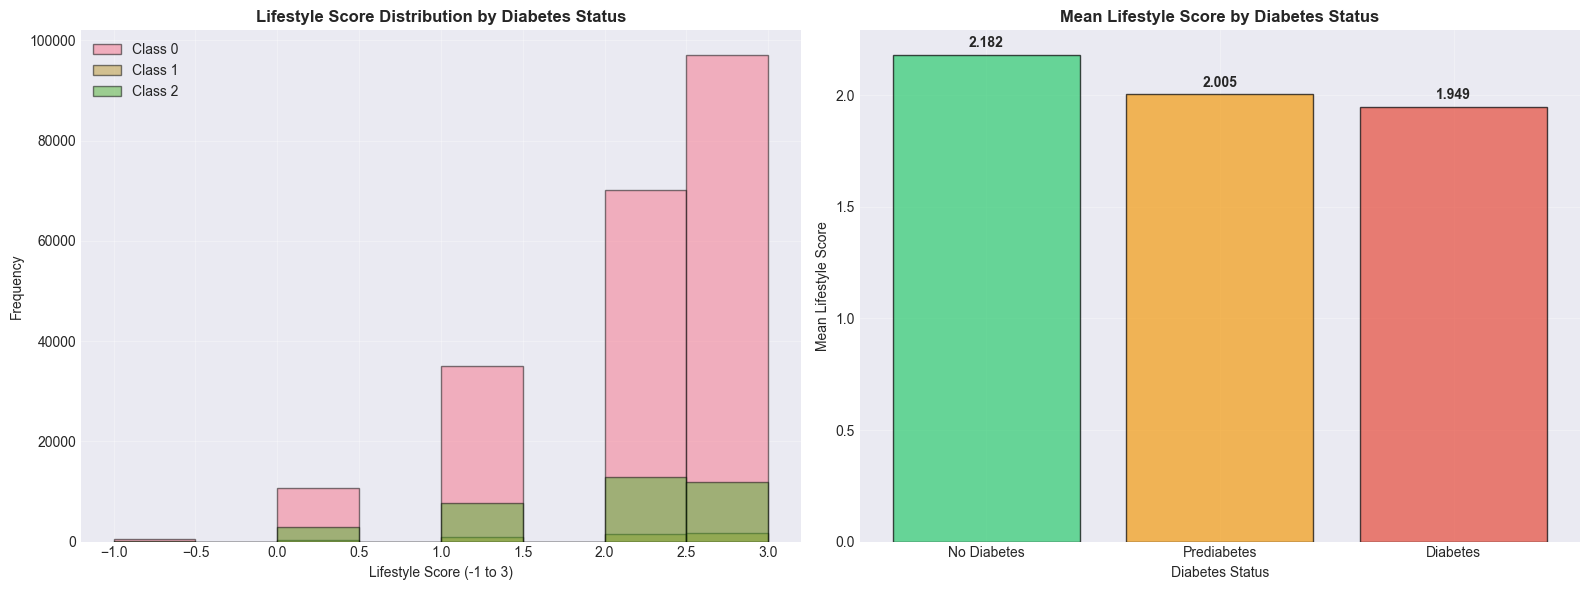

In [36]:
# Visualize lifestyle score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
for diabetes_class in sorted(df['Diabetes_012'].unique()):
    data = df[df['Diabetes_012'] == diabetes_class]['LifestyleScore']
    axes[0].hist(data, bins=8, alpha=0.5, label=f'Class {int(diabetes_class)}',
                edgecolor='black')
axes[0].set_title('Lifestyle Score Distribution by Diabetes Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lifestyle Score (-1 to 3)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar plot of means
lifestyle_means = df.groupby('Diabetes_012')['LifestyleScore'].mean()
axes[1].bar([0, 1, 2], lifestyle_means.values, color=['#2ecc71', '#f39c12', '#e74c3c'],
           alpha=0.7, edgecolor='black')
axes[1].set_title('Mean Lifestyle Score by Diabetes Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diabetes Status', fontsize=10)
axes[1].set_ylabel('Mean Lifestyle Score', fontsize=10)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1].grid(alpha=0.3)
for i, v in enumerate(lifestyle_means.values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Socioeconomic Factors Analysis

Understanding the role of education, income, and healthcare access

In [37]:
# Education level by diabetes status
print("Education Level Distribution by Diabetes Status (%):\n")
education_diabetes = pd.crosstab(df['Diabetes_012'], df['Education'], normalize='index') * 100
print(education_diabetes)

# Income level by diabetes status
print("\nIncome Level Distribution by Diabetes Status (%):\n")
income_diabetes = pd.crosstab(df['Diabetes_012'], df['Income'], normalize='index') * 100
print(income_diabetes)

Education Level Distribution by Diabetes Status (%):

Education          1.0       2.0       3.0        4.0        5.0        6.0
Diabetes_012                                                               
0.0           0.058492  1.262968  3.213806  23.553249  27.244821  44.666664
1.0           0.043187  3.476571  6.780393  29.151371  28.784280  31.764198
2.0           0.132971  3.346913  6.495785  31.307644  29.293272  29.423414

Income Level Distribution by Diabetes Status (%):

Income             1.0       2.0        3.0        4.0        5.0        6.0  \
Diabetes_012                                                                   
0.0           3.328919  3.903080   5.617609   7.310145   9.729391  14.239856   
1.0           6.780393  7.687325   9.090909   9.911466  12.675448  16.152019   
2.0           6.741923  8.730832  10.094494  11.469473  12.742602  14.969162   

Income              7.0        8.0  
Diabetes_012                        
0.0           17.416227  38.454771  
1.

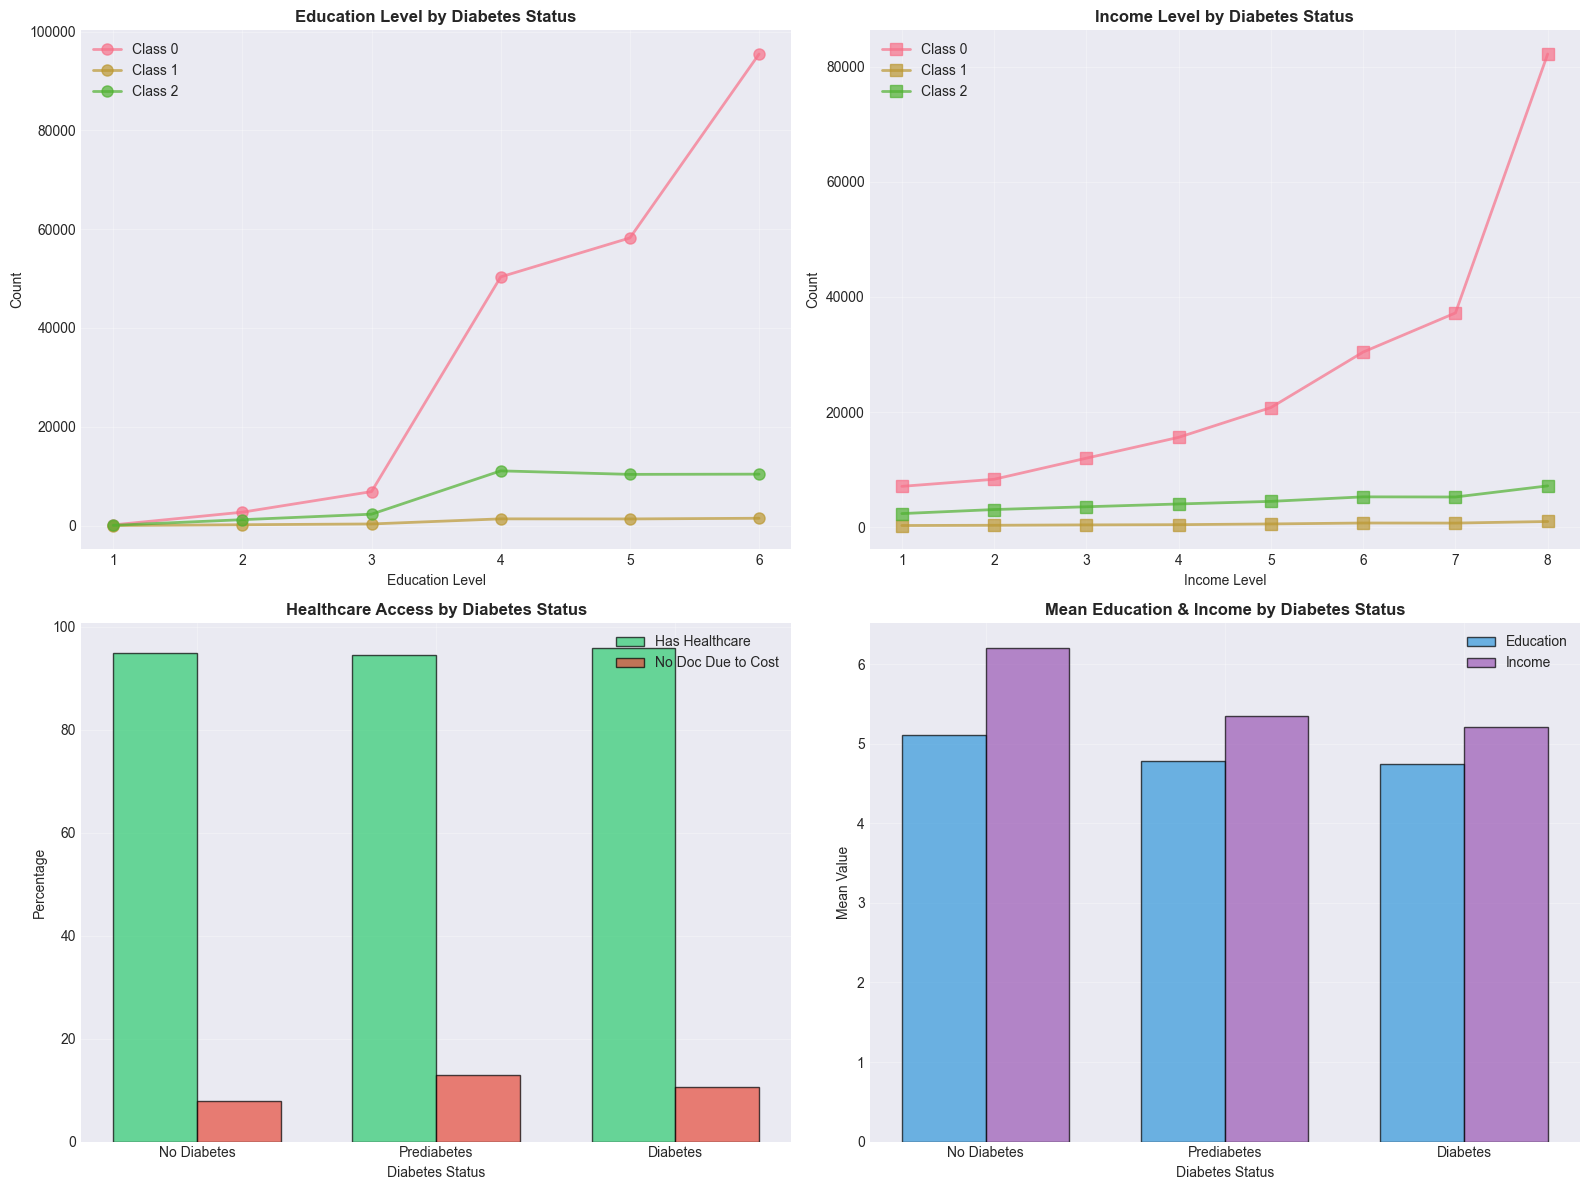

In [38]:
# Visualize socioeconomic factors
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Education by diabetes
for diabetes_class in sorted(df['Diabetes_012'].unique()):
    data = df[df['Diabetes_012'] == diabetes_class]['Education']
    education_counts = data.value_counts().sort_index()
    axes[0, 0].plot(education_counts.index, education_counts.values,
                   marker='o', linewidth=2, markersize=8,
                   label=f'Class {int(diabetes_class)}', alpha=0.7)
axes[0, 0].set_title('Education Level by Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Education Level', fontsize=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Income by diabetes
for diabetes_class in sorted(df['Diabetes_012'].unique()):
    data = df[df['Diabetes_012'] == diabetes_class]['Income']
    income_counts = data.value_counts().sort_index()
    axes[0, 1].plot(income_counts.index, income_counts.values,
                   marker='s', linewidth=2, markersize=8,
                   label=f'Class {int(diabetes_class)}', alpha=0.7)
axes[0, 1].set_title('Income Level by Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Income Level', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Healthcare access
healthcare_data = df.groupby('Diabetes_012')[['AnyHealthcare', 'NoDocbcCost']].mean() * 100
x = np.arange(len(healthcare_data.index))
width = 0.35
axes[1, 0].bar(x - width/2, healthcare_data['AnyHealthcare'], width,
              label='Has Healthcare', color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].bar(x + width/2, healthcare_data['NoDocbcCost'], width,
              label='No Doc Due to Cost', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Healthcare Access by Diabetes Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Diabetes Status', fontsize=10)
axes[1, 0].set_ylabel('Percentage', fontsize=10)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Mean income and education by diabetes
mean_values = df.groupby('Diabetes_012')[['Education', 'Income']].mean()
x = np.arange(len(mean_values.index))
width = 0.35
axes[1, 1].bar(x - width/2, mean_values['Education'], width,
              label='Education', color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 1].bar(x + width/2, mean_values['Income'], width,
              label='Income', color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Mean Education & Income by Diabetes Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diabetes Status', fontsize=10)
axes[1, 1].set_ylabel('Mean Value', fontsize=10)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Age-Based Analysis

Diabetes prevalence and health patterns across age groups

In [39]:
# Diabetes prevalence by age
print("Diabetes Prevalence by Age Group (%):\n")
age_diabetes = pd.crosstab(df['Age'], df['Diabetes_012'], normalize='index') * 100
print(age_diabetes)

Diabetes Prevalence by Age Group (%):

Diabetes_012        0.0       1.0        2.0
Age                                         
1.0           98.263158  0.368421   1.368421
2.0           97.446696  0.710713   1.842590
3.0           96.529713  0.647307   2.822979
4.0           94.444043  1.027273   4.528684
5.0           92.486229  1.008851   6.504920
6.0           89.636208  1.574247   8.789545
7.0           86.676294  1.588508  11.735198
8.0           84.389595  1.783861  13.826544
9.0           80.643124  2.111659  17.245217
10.0          77.464745  2.165000  20.370255
11.0          75.595972  2.558110  21.845918
12.0          75.919900  2.784731  21.295369
13.0          78.909175  2.608996  18.481829


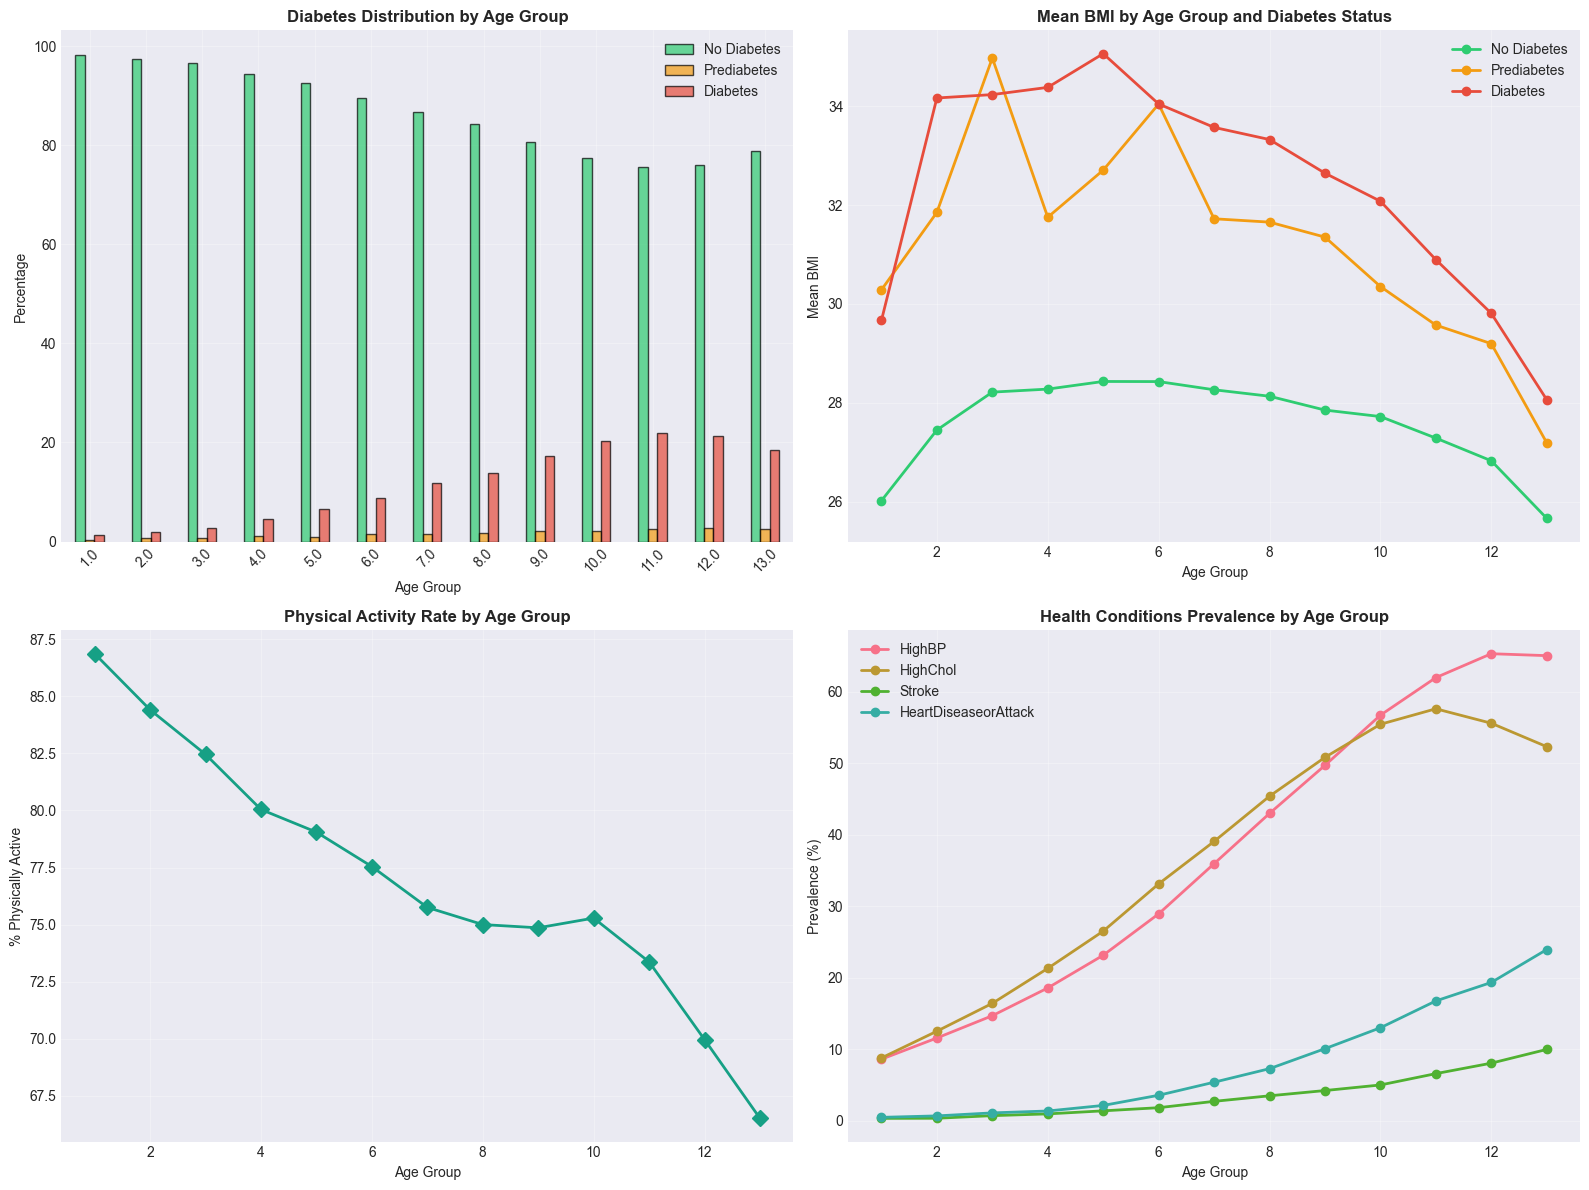

In [40]:
# Visualize age analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Diabetes distribution by age
age_diabetes.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#f39c12', '#e74c3c'],
                  alpha=0.7, edgecolor='black', stacked=False)
axes[0, 0].set_title('Diabetes Distribution by Age Group', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age Group', fontsize=10)
axes[0, 0].set_ylabel('Percentage', fontsize=10)
axes[0, 0].legend(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3)

# Mean BMI by age and diabetes
bmi_age_diabetes = df.groupby(['Age', 'Diabetes_012'])['BMI'].mean().unstack()
bmi_age_diabetes.plot(kind='line', ax=axes[0, 1], marker='o', linewidth=2, markersize=6,
                      color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 1].set_title('Mean BMI by Age Group and Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age Group', fontsize=10)
axes[0, 1].set_ylabel('Mean BMI', fontsize=10)
axes[0, 1].legend(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[0, 1].grid(alpha=0.3)

# Physical activity by age
physactivity_age = df.groupby('Age')['PhysActivity'].mean() * 100
axes[1, 0].plot(physactivity_age.index, physactivity_age.values,
               marker='D', linewidth=2, markersize=8, color='#16a085')
axes[1, 0].set_title('Physical Activity Rate by Age Group', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age Group', fontsize=10)
axes[1, 0].set_ylabel('% Physically Active', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Health conditions by age
health_by_age = df.groupby('Age')[health_conditions].mean() * 100
health_by_age.plot(kind='line', ax=axes[1, 1], marker='o', linewidth=2, markersize=6)
axes[1, 1].set_title('Health Conditions Prevalence by Age Group', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age Group', fontsize=10)
axes[1, 1].set_ylabel('Prevalence (%)', fontsize=10)
axes[1, 1].legend(health_conditions, loc='upper left')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. General Health Status Analysis

Examining general health, mental health, and physical health patterns

In [41]:
# General health by diabetes
print("General Health Distribution by Diabetes Status (%):\n")
genhealth_diabetes = pd.crosstab(df['Diabetes_012'], df['GenHlth'], normalize='index') * 100
print(genhealth_diabetes)

# Mental and physical health by diabetes
print("\nMean Mental & Physical Health Days by Diabetes Status:\n")
health_days = df.groupby('Diabetes_012')[['MentHlth', 'PhysHlth']].mean()
print(health_days)

General Health Distribution by Diabetes Status (%):

GenHlth             1.0        2.0        3.0        4.0        5.0
Diabetes_012                                                       
0.0           20.517260  38.131893  28.292069   9.712077   3.346701
1.0            6.758799  26.214640  37.313755  22.133448   7.579357
2.0            3.225259  18.052962  38.072201  27.697618  12.951961

Mean Mental & Physical Health Days by Diabetes Status:

              MentHlth  PhysHlth
Diabetes_012                    
0.0           2.944404  3.582416
1.0           4.529907  6.348305
2.0           4.461806  7.954479


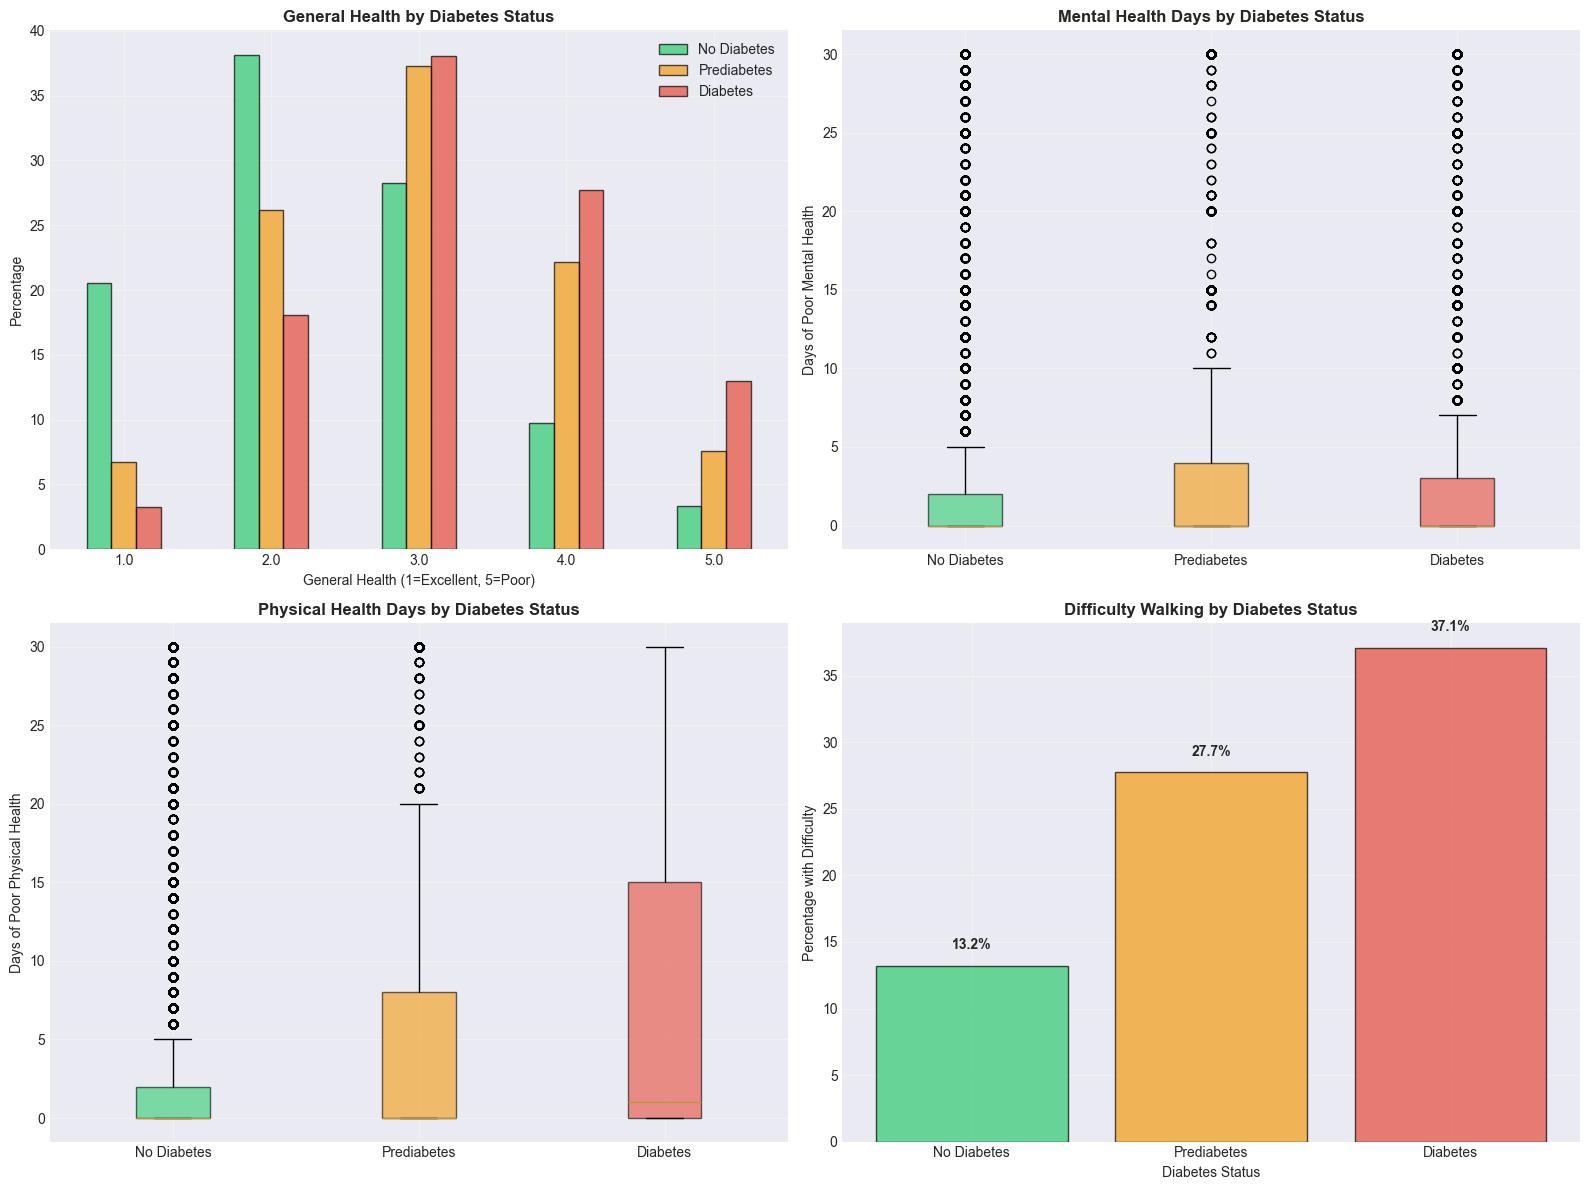

In [42]:
# Visualize general health analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# General health distribution
genhealth_diabetes.T.plot(kind='bar', ax=axes[0, 0],
                          color=['#2ecc71', '#f39c12', '#e74c3c'],
                          alpha=0.7, edgecolor='black')
axes[0, 0].set_title('General Health by Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('General Health (1=Excellent, 5=Poor)', fontsize=10)
axes[0, 0].set_ylabel('Percentage', fontsize=10)
axes[0, 0].legend(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].grid(alpha=0.3)

# Mental health days
mental_health_data = [df[df['Diabetes_012'] == cls]['MentHlth']
                      for cls in sorted(df['Diabetes_012'].unique())]
bp = axes[0, 1].boxplot(mental_health_data, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
                        patch_artist=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 1].set_title('Mental Health Days by Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Days of Poor Mental Health', fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Physical health days
physical_health_data = [df[df['Diabetes_012'] == cls]['PhysHlth']
                        for cls in sorted(df['Diabetes_012'].unique())]
bp = axes[1, 0].boxplot(physical_health_data, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 0].set_title('Physical Health Days by Diabetes Status', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Days of Poor Physical Health', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Difficulty walking
diffwalk_diabetes = df.groupby('Diabetes_012')['DiffWalk'].mean() * 100
axes[1, 1].bar([0, 1, 2], diffwalk_diabetes.values,
              color=['#2ecc71', '#f39c12', '#e74c3c'],
              alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Difficulty Walking by Diabetes Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diabetes Status', fontsize=10)
axes[1, 1].set_ylabel('Percentage with Difficulty', fontsize=10)
axes[1, 1].set_xticks([0, 1, 2])
axes[1, 1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1, 1].grid(alpha=0.3)
for i, v in enumerate(diffwalk_diabetes.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 15. BMI Analysis (Key Risk Factor)

In-depth analysis of Body Mass Index and its relationship with diabetes

In [43]:
# Create BMI categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

print("BMI Category Distribution:")
print(df['BMI_Category'].value_counts())

print("\nBMI Statistics by Diabetes Status:")
print(df.groupby('Diabetes_012')['BMI'].describe())

print("\nDiabetes Distribution by BMI Category (%):\n")
bmi_cat_diabetes = pd.crosstab(df['BMI_Category'], df['Diabetes_012'], normalize='index') * 100
print(bmi_cat_diabetes)

BMI Category Distribution:
BMI_Category
Overweight     93749
Obese          87851
Normal         68953
Underweight     3127
Name: count, dtype: int64

BMI Statistics by Diabetes Status:
                 count       mean       std   min   25%   50%   75%   max
Diabetes_012                                                             
0.0           213703.0  27.742521  6.260993  12.0  24.0  27.0  30.0  98.0
1.0             4631.0  30.724466  6.964898  13.0  26.0  30.0  34.0  96.0
2.0            35346.0  31.944011  7.363401  13.0  27.0  31.0  35.0  98.0

Diabetes Distribution by BMI Category (%):

Diabetes_012        0.0       1.0        2.0
BMI_Category                                
Normal        93.304135  0.999231   5.696634
Obese         73.881914  2.718239  23.399847
Overweight    86.967328  1.627751  11.404922
Underweight   93.700032  0.895427   5.404541


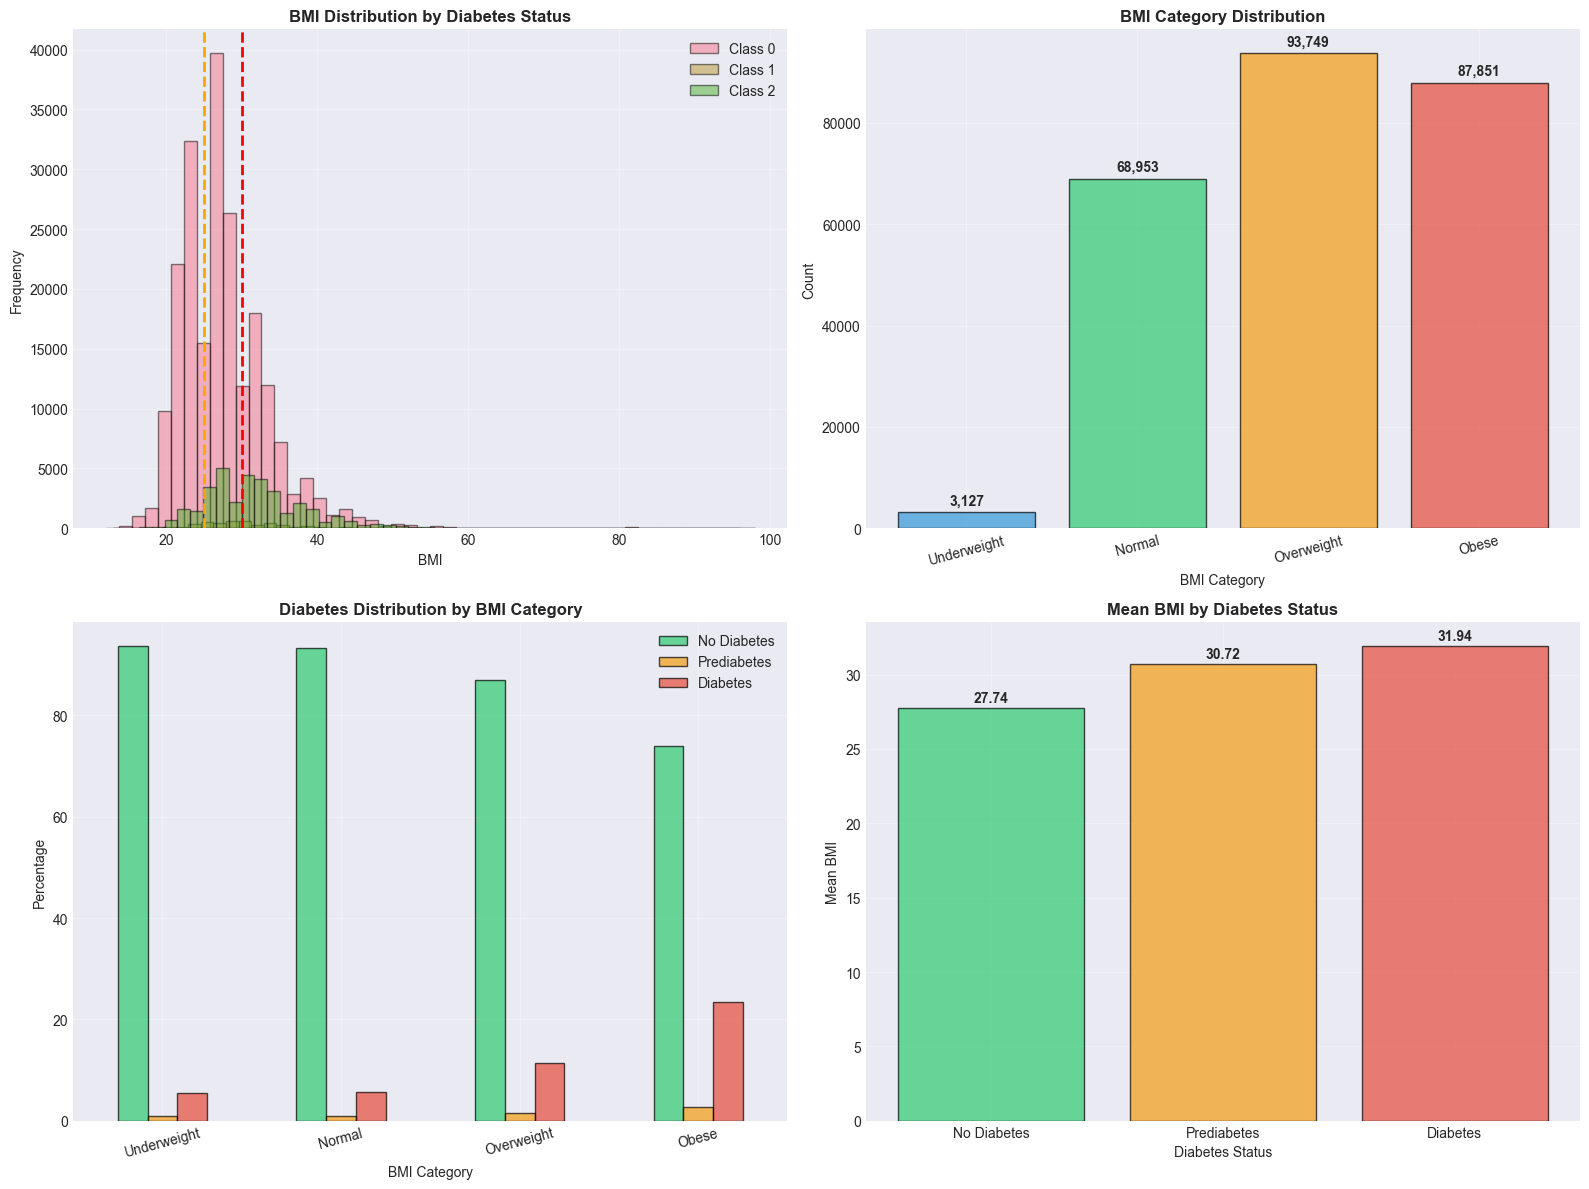

In [44]:
# Visualize BMI analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# BMI distribution by diabetes
for diabetes_class in sorted(df['Diabetes_012'].unique()):
    data = df[df['Diabetes_012'] == diabetes_class]['BMI']
    axes[0, 0].hist(data, bins=50, alpha=0.5, label=f'Class {int(diabetes_class)}',
                   edgecolor='black')
axes[0, 0].set_title('BMI Distribution by Diabetes Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('BMI', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].legend()
axes[0, 0].axvline(x=25, color='orange', linestyle='--', linewidth=2)
axes[0, 0].axvline(x=30, color='red', linestyle='--', linewidth=2)
axes[0, 0].grid(alpha=0.3)

# BMI categories distribution
bmi_cat_counts = df['BMI_Category'].value_counts()
order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_cat_counts = bmi_cat_counts.reindex(order)
axes[0, 1].bar(range(len(bmi_cat_counts)), bmi_cat_counts.values,
              color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
              alpha=0.7, edgecolor='black')
axes[0, 1].set_title('BMI Category Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI Category', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].set_xticks(range(len(bmi_cat_counts)))
axes[0, 1].set_xticklabels(order, rotation=15)
axes[0, 1].grid(alpha=0.3)
for i, v in enumerate(bmi_cat_counts.values):
    axes[0, 1].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Diabetes by BMI category
bmi_cat_diabetes_reindex = bmi_cat_diabetes.reindex(order)
bmi_cat_diabetes_reindex.plot(kind='bar', ax=axes[1, 0],
                              color=['#2ecc71', '#f39c12', '#e74c3c'],
                              alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Diabetes Distribution by BMI Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('BMI Category', fontsize=10)
axes[1, 0].set_ylabel('Percentage', fontsize=10)
axes[1, 0].legend(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(alpha=0.3)

# Mean BMI by diabetes status
mean_bmi = df.groupby('Diabetes_012')['BMI'].mean()
axes[1, 1].bar([0, 1, 2], mean_bmi.values,
              color=['#2ecc71', '#f39c12', '#e74c3c'],
              alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Mean BMI by Diabetes Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diabetes Status', fontsize=10)
axes[1, 1].set_ylabel('Mean BMI', fontsize=10)
axes[1, 1].set_xticks([0, 1, 2])
axes[1, 1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])
axes[1, 1].grid(alpha=0.3)
for i, v in enumerate(mean_bmi.values):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 16. Key Findings and Insights Summary

In [45]:
print("="*80)
print("KEY FINDINGS AND INSIGHTS")
print("="*80)

print("\nA. TARGET VARIABLE DISTRIBUTION:")
print("-" * 40)
for cls in sorted(df['Diabetes_012'].unique()):
    count = target_counts[cls]
    pct = target_percentages[cls]
    class_name = ['No Diabetes', 'Prediabetes', 'Diabetes'][int(cls)]
    print(f"  {class_name}: {count:,} samples ({pct:.2f}%)")

print("\nB. STRONGEST POSITIVE CORRELATIONS WITH DIABETES:")
print("-" * 40)
top_positive = diabetes_corr[diabetes_corr > 0].sort_values(ascending=False)[1:11]
for feature, corr in top_positive.items():
    print(f"  {feature:25} : {corr:.4f}")

print("\nC. STRONGEST NEGATIVE CORRELATIONS WITH DIABETES:")
print("-" * 40)
top_negative = diabetes_corr[diabetes_corr < 0].sort_values()[0:5]
for feature, corr in top_negative.items():
    print(f"  {feature:25} : {corr:.4f}")

print("\nD. BMI STATISTICS BY DIABETES STATUS:")
print("-" * 40)
for cls in sorted(df['Diabetes_012'].unique()):
    mean_bmi_val = df[df['Diabetes_012'] == cls]['BMI'].mean()
    median_bmi = df[df['Diabetes_012'] == cls]['BMI'].median()
    class_name = ['No Diabetes', 'Prediabetes', 'Diabetes'][int(cls)]
    print(f"  {class_name}: Mean={mean_bmi_val:.2f}, Median={median_bmi:.2f}")

print("\nE. PREVALENCE OF KEY HEALTH CONDITIONS BY DIABETES STATUS (%):")
print("-" * 40)
for condition in health_conditions:
    print(f"\n  {condition}:")
    for cls in sorted(df['Diabetes_012'].unique()):
        prevalence = df[df['Diabetes_012'] == cls][condition].mean() * 100
        class_name = ['No Diabetes', 'Prediabetes', 'Diabetes'][int(cls)]
        print(f"    {class_name}: {prevalence:.2f}%")

print("\nF. LIFESTYLE FACTORS BY DIABETES STATUS (%):")
print("-" * 40)
for lifestyle in ['PhysActivity', 'Fruits', 'Veggies']:
    print(f"\n  {lifestyle}:")
    for cls in sorted(df['Diabetes_012'].unique()):
        rate = df[df['Diabetes_012'] == cls][lifestyle].mean() * 100
        class_name = ['No Diabetes', 'Prediabetes', 'Diabetes'][int(cls)]
        print(f"    {class_name}: {rate:.2f}%")

print("\nG. AGE DISTRIBUTION BY DIABETES STATUS:")
print("-" * 40)
for cls in sorted(df['Diabetes_012'].unique()):
    mean_age = df[df['Diabetes_012'] == cls]['Age'].mean()
    median_age = df[df['Diabetes_012'] == cls]['Age'].median()
    class_name = ['No Diabetes', 'Prediabetes', 'Diabetes'][int(cls)]
    print(f"  {class_name}: Mean Age Group={mean_age:.2f}, Median={median_age:.2f}")

print("\nH. DATA QUALITY SUMMARY:")
print("-" * 40)
print(f"  Total records: {len(df):,}")
print(f"  Duplicate records: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Features: {df.shape[1]}")

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nKey Takeaways:")
print("1. Strong class imbalance exists - consider resampling techniques")
print("2. BMI, Age, and General Health are strong predictors")
print("3. Co-morbidities (HighBP, HighChol) highly associated with diabetes")
print("4. Physical activity shows protective effect")
print("5. Socioeconomic factors play a role in diabetes prevalence")
print("\nRecommended next steps:")
print("- Feature engineering (create interaction terms, composite scores)")
print("- Handle class imbalance (SMOTE, class weights)")
print("- Feature scaling and normalization")
print("- Build and evaluate classification models")
print("="*80)

KEY FINDINGS AND INSIGHTS

A. TARGET VARIABLE DISTRIBUTION:
----------------------------------------
  No Diabetes: 213,703 samples (84.24%)
  Prediabetes: 4,631 samples (1.83%)
  Diabetes: 35,346 samples (13.93%)

B. STRONGEST POSITIVE CORRELATIONS WITH DIABETES:
----------------------------------------
  GenHlth                   : 0.3026
  HighBP                    : 0.2716
  BMI                       : 0.2244
  DiffWalk                  : 0.2242
  HighChol                  : 0.2091
  Age                       : 0.1850
  HeartDiseaseorAttack      : 0.1803
  PhysHlth                  : 0.1763
  Stroke                    : 0.1072
  MentHlth                  : 0.0735

C. STRONGEST NEGATIVE CORRELATIONS WITH DIABETES:
----------------------------------------
  Income                    : -0.1715
  Education                 : -0.1305
  PhysActivity              : -0.1219
  Veggies                   : -0.0590
  HvyAlcoholConsump         : -0.0579

D. BMI STATISTICS BY DIABETES STATUS:
---